In [ ]:
import pandas as pd
import sys
import datetime as dt

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

In [ ]:
sys.path.insert(0, '')
from Clase_Valor_240902 import Valor
from Transversal import leer_activos, leer_parametros, leer_configuracion

In [ ]:
carpeta_input, cofre, seguimiento, saving_step = leer_parametros()
output_level = leer_configuracion()

In [ ]:
df_activos = leer_activos(carpeta_input)
df_activos

In [ ]:
simbolo, nombre = 'BTC-USD', 'BTC-USD'

In [ ]:
valor = Valor(simbolo, nombre, cofre) # Si no existe el objeto, se crea 
valor.extraer_data(reextraer_todo = True)
df_data = valor.raw_data

In [ ]:
# En general, desde que día se considerarán todos los análisis
date_0 = dt.datetime(2021, 1, 1) # Día de referencia para obtener t
df_data['Date'] = pd.to_datetime(df_data['Date'])
df_data = df_data[df_data.Date >= date_0].reset_index(drop = True)
df_data

In [ ]:
import pandas as pd
import mplfinance as mpf

# Supongamos que tienes un DataFrame 'df' con las siguientes columnas: 'Date', 'Open', 'High', 'Low', 'Close', 'Volume'
# Aquí hay un ejemplo de cómo podría verse:

df_plot_all = df_data.copy()
df_plot_all = df_plot_all.set_index('Date')

# Crear el gráfico de velas
mpf.plot(df_plot_all, type = 'candle', volume = False, style = 'charles', figsize = (21, 7))

In [ ]:
campos_modo_vela = {'area': ['Open', 'Close'], 'extremos': ['Low', 'High']} # Campos asociados a los modos de vela
modo_vela = 'extremos' # area o extremos (Parámetro)

# Mínimos y máximos - Soportes y resistencias

In [ ]:
import numpy as np

In [ ]:
# Además, evaluar peso de máximo y mínimo (extremo), contando la distancia que tiene hasta tocar un precio a la derecha y un precio a la izquierda (si se acaba el horironte a la derecha o a la izq llega hasta ahi)
#           El peso es P = min(dist izq, dist der)


In [161]:
df_data.head()

In [162]:

df_precios = df_data.reset_index()
df_precios['t'] = (df_precios['Date'] - date_0).dt.days # Se crea la columna t (date_0 es un día de referencia)

df_date = df_precios[['Date', 't']]
df = df_precios[['Date', 't'] + campos_modo_vela[modo_vela]]#.reset_index()
df

,Date,t,Low,High
0,2021-01-01,0,28803.585938,29600.626953
1,2021-01-02,1,29091.181641,33155.117188
2,2021-01-03,2,32052.316406,34608.558594
3,2021-01-04,3,28722.755859,33440.218750
4,2021-01-05,4,30221.187500,34437.589844
...,...,...,...,...
1672,2025-07-31,1672,115505.218750,118919.984375
1673,2025-08-01,1673,112724.445312,116060.773438
1674,2025-08-02,1674,112005.765625,114021.601562
1675,2025-08-03,1675,111943.804688,114747.421875


In [163]:
def calcular_distancias(df):
    n = len(df)
    df = df.copy()
    
    df["Low_left"] = np.nan
    df["Low_right"] = np.nan
    df["High_left"] = np.nan
    df["High_right"] = np.nan
    
    max_t = df["t"].max()

    for i in range(n):
        low_val = df.loc[i, "Low"]
        high_val = df.loc[i, "High"]
        t_i = df.loc[i, "t"]
        
        # Buscar hacia la izquierda (Low)
        for j in range(i-1, -1, -1):
            if df.loc[j, "Low"] <= low_val <= df.loc[j, "High"]:
                df.loc[i, "Low_left"] = t_i - df.loc[j, "t"]
                break

        # Buscar hacia la izquierda (High)
        for j in range(i-1, -1, -1):
            if df.loc[j, "Low"] <= high_val <= df.loc[j, "High"]:
                df.loc[i, "High_left"] = t_i - df.loc[j, "t"]
                break

        # Buscar hacia la derecha (Low)
        for j in range(i+1, n):
            if df.loc[j, "Low"] <= low_val <= df.loc[j, "High"]:
                df.loc[i, "Low_right"] = df.loc[j, "t"] - t_i
                break

        # Buscar hacia la derecha (High)
        for j in range(i+1, n):
            if df.loc[j, "Low"] <= high_val <= df.loc[j, "High"]:
                df.loc[i, "High_right"] = df.loc[j, "t"] - t_i
                break

    # Rellenar los NaN con t o max(t) - t
    df["Low_left"] = df["Low_left"].fillna(df["t"])
    df["High_left"] = df["High_left"].fillna(df["t"])
    df["Low_right"] = df["Low_right"].fillna(max_t - df["t"])
    df["High_right"] = df["High_right"].fillna(max_t - df["t"])

    return df

df_extremos = df[df['Date'] >= "2025-01-01"].reset_index(drop = True) # Filtrar por fecha
df_extremos = calcular_distancias(df_extremos)


In [164]:
# Generación de algunas columnas adicionales para análisis
df_extremos['min_low'] = df_extremos[['Low_left', 'Low_right']].min(axis = 1)
df_extremos['min_high'] = df_extremos[['High_left', 'High_right']].min(axis = 1)
df_extremos['max_low'] = df_extremos[['Low_left', 'Low_right']].max(axis = 1)
df_extremos['max_high'] = df_extremos[['High_left', 'High_right']].max(axis = 1)
df_extremos['avg_low'] = (df_extremos['Low_left'] + df_extremos['Low_right']) / 2
df_extremos['avg_high'] = (df_extremos['High_left'] + df_extremos['High_right']) / 2

df_extremos

,Date,t,Low,High,Low_left,Low_right,High_left,High_right,min_low,min_high,max_low,max_high,avg_low,avg_high
0,2025-01-01,1461,92788.125000,94929.867188,1461.0,7.0,1461.0,1.0,7.0,1.0,1461.0,1461.0,734.0,731.0
1,2025-01-02,1462,94201.570312,97739.820312,1.0,6.0,1462.0,1.0,1.0,1.0,6.0,1462.0,3.5,731.5
2,2025-01-03,1463,96034.617188,98956.914062,1.0,5.0,1463.0,3.0,1.0,3.0,5.0,1463.0,3.0,733.0
3,2025-01-04,1464,97562.976562,98734.429688,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,2025-01-05,1465,97291.765625,98813.304688,2.0,2.0,2.0,1.0,2.0,1.0,2.0,2.0,2.0,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,2025-07-31,1672,115505.218750,118919.984375,6.0,1.0,2.0,4.0,1.0,2.0,6.0,4.0,3.5,3.0
212,2025-08-01,1673,112724.445312,116060.773438,22.0,1.0,1.0,3.0,1.0,1.0,22.0,3.0,11.5,2.0
213,2025-08-02,1674,112005.765625,114021.601562,23.0,1.0,1.0,1.0,1.0,1.0,23.0,1.0,12.0,1.0
214,2025-08-03,1675,111943.804688,114747.421875,24.0,1.0,2.0,1.0,1.0,1.0,24.0,2.0,12.5,1.5


Tiempo de recuperación

,Date,price,rec_time
0,2025-01-01,94929.867188,1.0
1,2025-01-02,97739.820312,1.0
2,2025-01-03,98956.914062,3.0
3,2025-01-04,98734.429688,1.0
4,2025-01-05,98813.304688,1.0
...,...,...,...
427,2025-07-31,115505.218750,1.0
428,2025-08-01,112724.445312,1.0
429,2025-08-02,112005.765625,1.0
430,2025-08-03,111943.804688,1.0


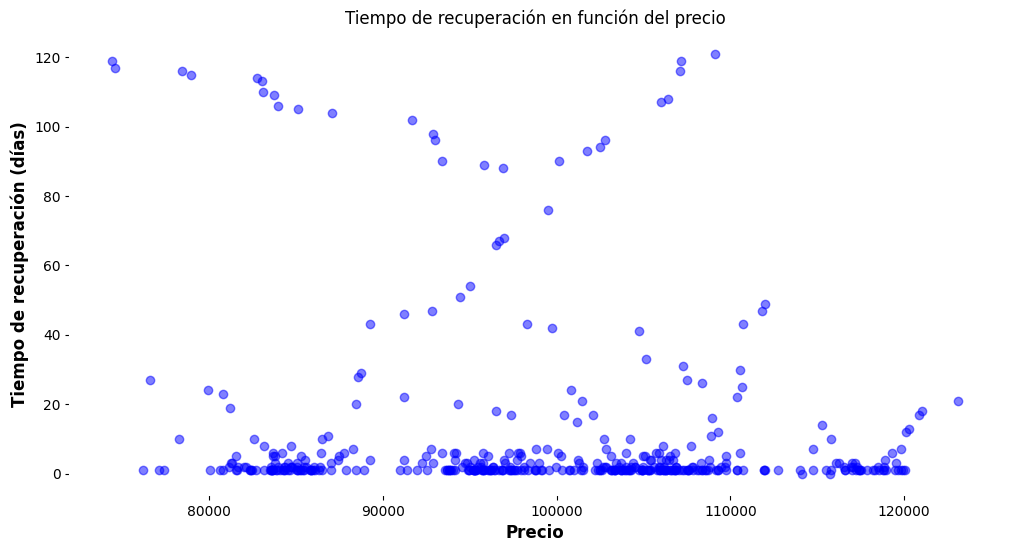

In [165]:
df_recovery_time_h = df_extremos[['Date', 'High', 'High_right']].rename(columns = {'High_right': 'rec_time', 'High': 'price'})
df_recovery_time_l = df_extremos[['Date', 'Low', 'Low_right']].rename(columns = {'Low_right': 'rec_time', 'Low': 'price'})

df_recovery_time = pd.concat([df_recovery_time_h, df_recovery_time_l], ignore_index = True)
display(df_recovery_time)

# Graficar rec_time en funcióon de price (scatter)
def graficar_rec_time(df):
    fig, ax = plt.subplots(figsize = (12, 6))
    
    # Graficar los puntos
    ax.scatter(df['price'], df['rec_time'], alpha = 0.5, color = 'blue')
    
    # Configurar etiquetas y título
    ax.set_xlabel('Precio')
    ax.set_ylabel('Tiempo de recuperación (días)')
    ax.set_title('Tiempo de recuperación en función del precio')
    
    plt.grid()
    plt.show()

graficar_rec_time(df_recovery_time)


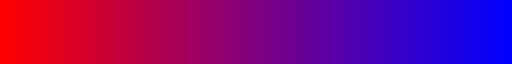

In [166]:
# de salmon a lightblue
s_l = mcolors.LinearSegmentedColormap.from_list("s_l", ["red", "blue"])  # Rojo a azul
s_l

,Date,Low,High,min_low,min_high
0,2025-01-01,92788.125000,94929.867188,0.058824,0.008264
1,2025-01-02,94201.570312,97739.820312,0.008403,0.008264
2,2025-01-03,96034.617188,98956.914062,0.008403,0.024793
3,2025-01-04,97562.976562,98734.429688,0.008403,0.008264
4,2025-01-05,97291.765625,98813.304688,0.016807,0.008264
...,...,...,...,...,...
211,2025-07-31,115505.218750,118919.984375,0.008403,0.016529
212,2025-08-01,112724.445312,116060.773438,0.008403,0.008264
213,2025-08-02,112005.765625,114021.601562,0.008403,0.008264
214,2025-08-03,111943.804688,114747.421875,0.008403,0.008264


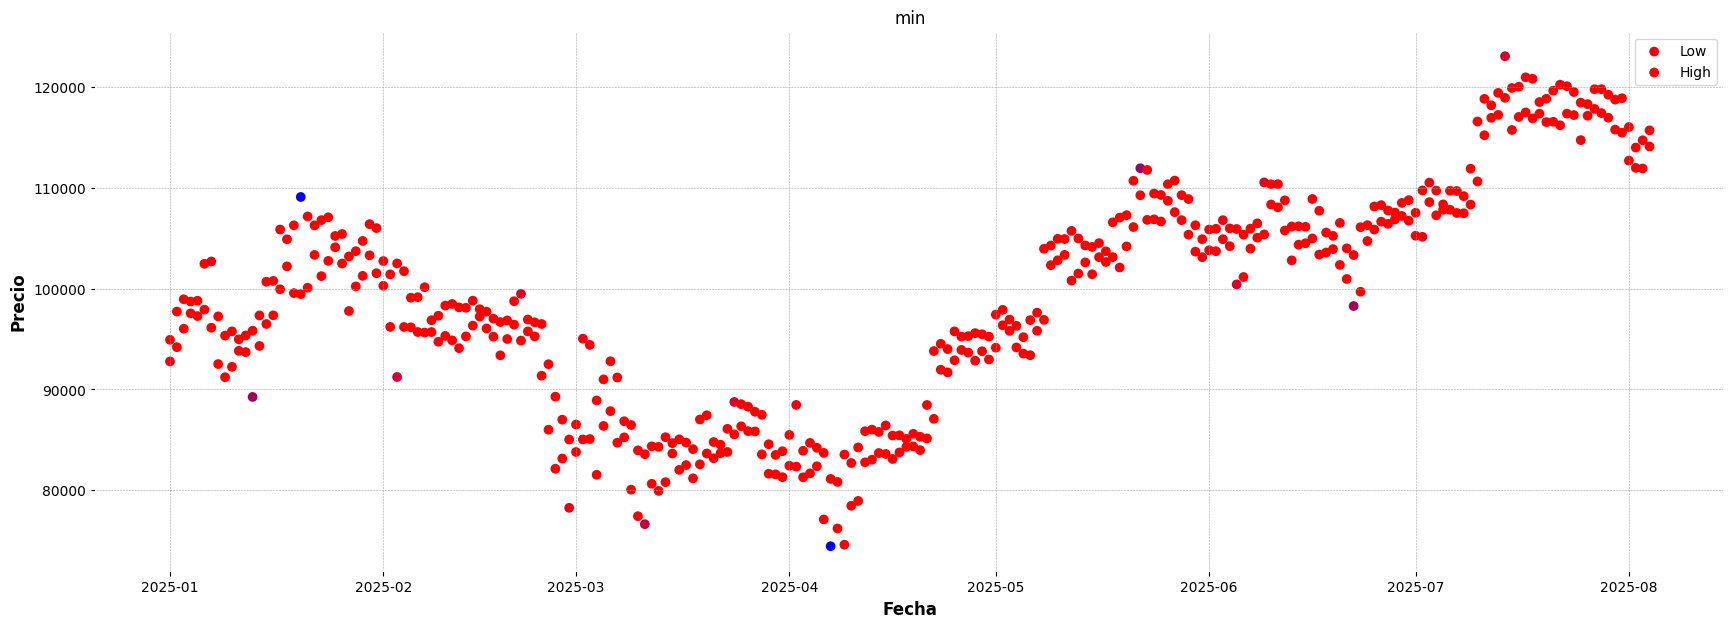

,Date,Low,High,max_low,max_high
0,2025-01-01,92788.125000,94929.867188,0.938343,0.882779
1,2025-01-02,94201.570312,97739.820312,0.003854,0.883384
2,2025-01-03,96034.617188,98956.914062,0.003211,0.883988
3,2025-01-04,97562.976562,98734.429688,0.000642,0.000604
4,2025-01-05,97291.765625,98813.304688,0.001285,0.001208
...,...,...,...,...,...
211,2025-07-31,115505.218750,118919.984375,0.003854,0.002417
212,2025-08-01,112724.445312,116060.773438,0.014130,0.001813
213,2025-08-02,112005.765625,114021.601562,0.014772,0.000604
214,2025-08-03,111943.804688,114747.421875,0.015414,0.001208


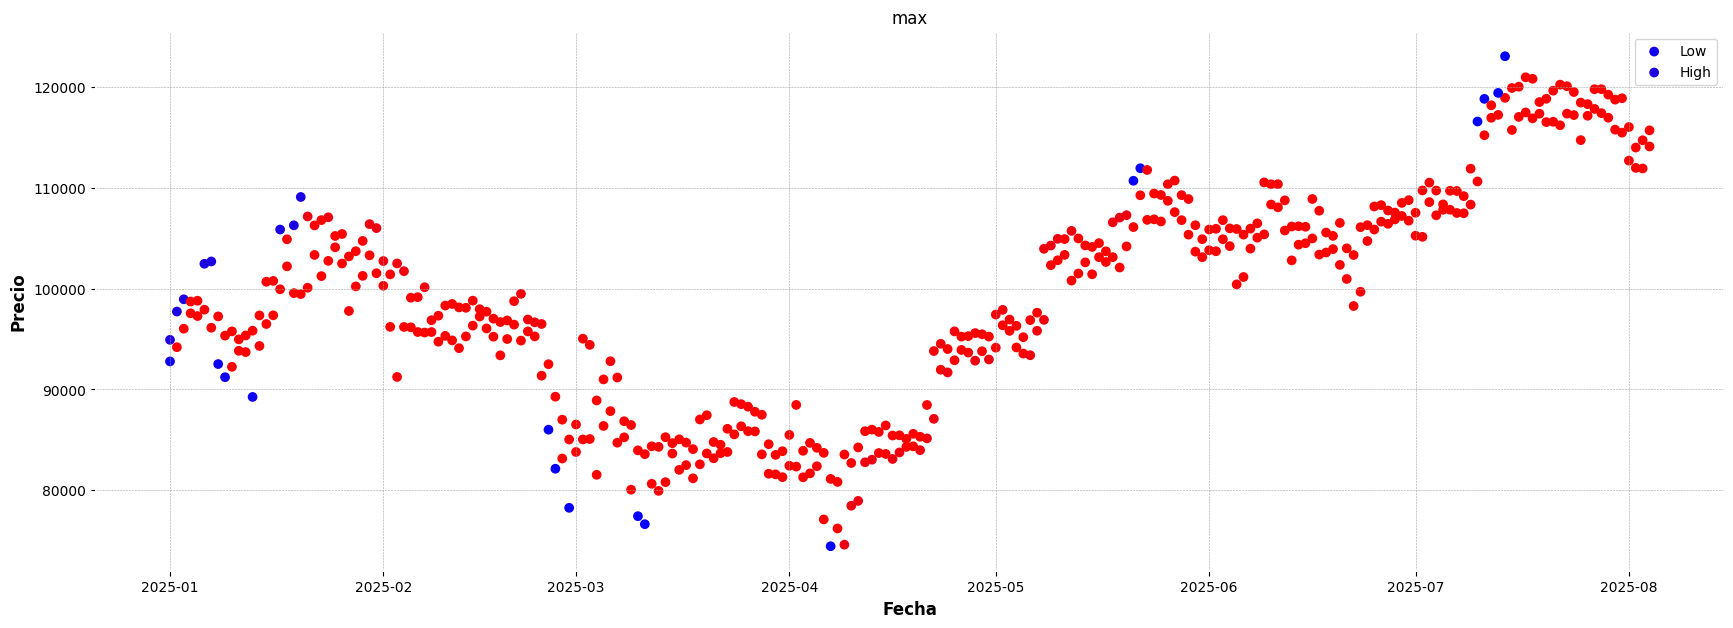

,Date,Low,High,avg_low,avg_high
0,2025-01-01,92788.125000,94929.867188,0.875895,0.872315
1,2025-01-02,94201.570312,97739.820312,0.004177,0.872912
2,2025-01-03,96034.617188,98956.914062,0.003580,0.874702
3,2025-01-04,97562.976562,98734.429688,0.001193,0.001193
4,2025-01-05,97291.765625,98813.304688,0.002387,0.001790
...,...,...,...,...,...
211,2025-07-31,115505.218750,118919.984375,0.004177,0.003580
212,2025-08-01,112724.445312,116060.773438,0.013723,0.002387
213,2025-08-02,112005.765625,114021.601562,0.014320,0.001193
214,2025-08-03,111943.804688,114747.421875,0.014916,0.001790


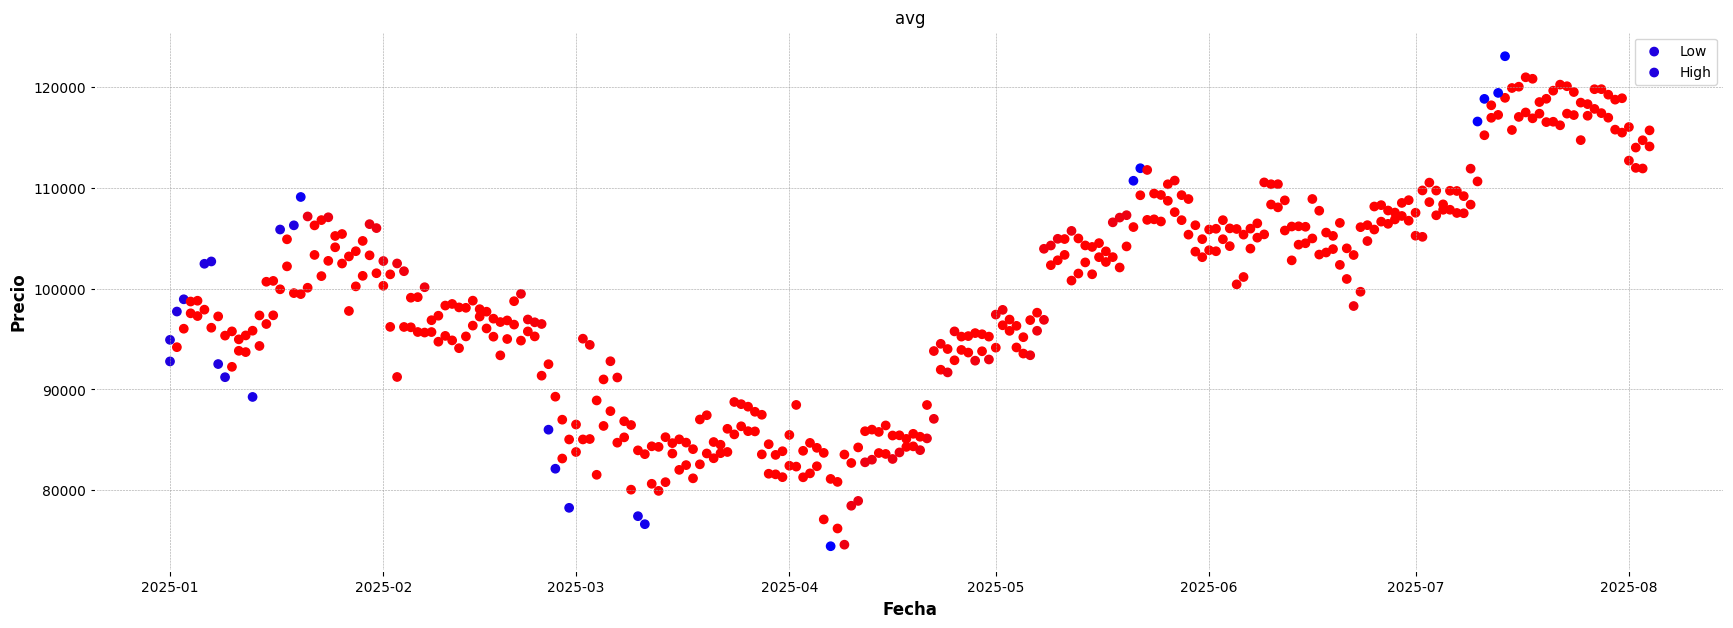

In [167]:
# Se normalizan las columnas adicionales
campos_analisis = ['min_low', 'min_high', 'max_low', 'max_high', 'avg_low', 'avg_high']
for c in campos_analisis:
    df_extremos[c] = df_extremos[c] / df_extremos[c].max() #KPIEXTREMOS1-6

df

for c in ['min', 'max', 'avg']:
    df_i = df_extremos[['Date', 'Low', 'High', f'{c}_low', f'{c}_high']]
    display(df_i)
    
    plt.figure(figsize = (21, 7))
    plt.scatter(df_i['Date'], df_i['Low'], c = df_i[f'{c}_low'], cmap = s_l, label = 'Low')
    plt.scatter(df_i['Date'], df_i['High'], c = df_i[f'{c}_high'], cmap = s_l, label = 'High')
    plt.xlabel('Fecha')
    plt.ylabel('Precio')
    plt.title(c)
    plt.legend()
    plt.show()
    
    #sys.exit()

In [168]:
for c in ['Low_left', 'Low_right', 'High_left', 'High_right']:
    df_sort = df_extremos.sort_values(by = c, ascending = False)
    df_sort = df_sort.head(5)
    print(c)
    display(df_sort)

Low_left


,Date,t,Low,High,Low_left,Low_right,High_left,High_right,min_low,min_high,max_low,max_high,avg_low,avg_high
96,2025-04-07,1557,74436.679688,81119.062500,1557.0,119.0,1.0,2.0,1.000000,0.008264,1.000000,0.001208,1.000000,0.001790
69,2025-03-11,1530,76624.250000,83577.757812,1530.0,27.0,1.0,1.0,0.226891,0.008264,0.982659,0.000604,0.928998,0.001193
68,2025-03-10,1529,77420.593750,83955.929688,1529.0,1.0,1.0,2.0,0.008403,0.008264,0.982017,0.001208,0.912888,0.001790
58,2025-02-28,1519,78248.914062,85036.320312,1519.0,10.0,1.0,1.0,0.084034,0.008264,0.975594,0.000604,0.912291,0.001193
56,2025-02-26,1517,82131.898438,89286.250000,1517.0,2.0,1.0,4.0,0.016807,0.008264,0.974310,0.002417,0.906325,0.002983


Low_right


,Date,t,Low,High,Low_left,Low_right,High_left,High_right,min_low,min_high,max_low,max_high,avg_low,avg_high
96,2025-04-07,1557,74436.679688,81119.062500,1557.0,119.0,1.0,2.0,1.000000,0.008264,1.000000,0.001208,1.000000,0.001790
98,2025-04-09,1559,74589.671875,83541.000000,2.0,117.0,3.0,2.0,0.016807,0.016529,0.075145,0.001813,0.071002,0.002983
99,2025-04-10,1560,78456.132812,82700.929688,1.0,116.0,1.0,1.0,0.008403,0.008264,0.074502,0.000604,0.069809,0.001193
100,2025-04-11,1561,78936.320312,84247.476562,1.0,115.0,7.0,1.0,0.008403,0.008264,0.073860,0.004230,0.069212,0.004773
101,2025-04-12,1562,82769.375000,85856.187500,1.0,114.0,10.0,1.0,0.008403,0.008264,0.073218,0.006042,0.068616,0.006563


High_left


,Date,t,Low,High,Low_left,Low_right,High_left,High_right,min_low,min_high,max_low,max_high,avg_low,avg_high
194,2025-07-14,1655,118959.195312,123091.609375,1.0,1.0,1655.0,21.0,0.008403,0.173554,0.000642,1.000000,0.001193,1.000000
193,2025-07-13,1654,117265.437500,119449.570312,1.0,2.0,1654.0,1.0,0.008403,0.008264,0.001285,0.999396,0.001790,0.987470
191,2025-07-11,1652,115245.687500,118856.476562,1.0,14.0,1652.0,2.0,0.008403,0.016529,0.008992,0.998187,0.008950,0.986874
190,2025-07-10,1651,110660.750000,116608.781250,1.0,25.0,1651.0,1.0,0.008403,0.008264,0.016057,0.997583,0.015513,0.985680
141,2025-05-22,1602,109285.070312,111970.171875,1.0,1.0,1602.0,49.0,0.008403,0.404959,0.000642,0.967976,0.001193,0.985084


High_right


,Date,t,Low,High,Low_left,Low_right,High_left,High_right,min_low,min_high,max_low,max_high,avg_low,avg_high
19,2025-01-20,1480,99471.359375,109114.882812,4.0,7.0,1480.0,121.0,0.033613,1.000000,0.004496,0.894260,0.006563,0.955251
20,2025-01-21,1481,100103.953125,107180.921875,1.0,6.0,1.0,119.0,0.008403,0.008264,0.003854,0.071903,0.004177,0.071599
23,2025-01-24,1484,102772.125000,107098.546875,1.0,2.0,3.0,116.0,0.008403,0.024793,0.001285,0.070091,0.001790,0.071002
29,2025-01-30,1490,103321.648438,106418.765625,1.0,1.0,6.0,108.0,0.008403,0.049587,0.000642,0.065257,0.001193,0.068019
30,2025-01-31,1491,101543.882812,106026.351562,2.0,1.0,1.0,107.0,0.008403,0.008264,0.001285,0.064653,0.001790,0.064439


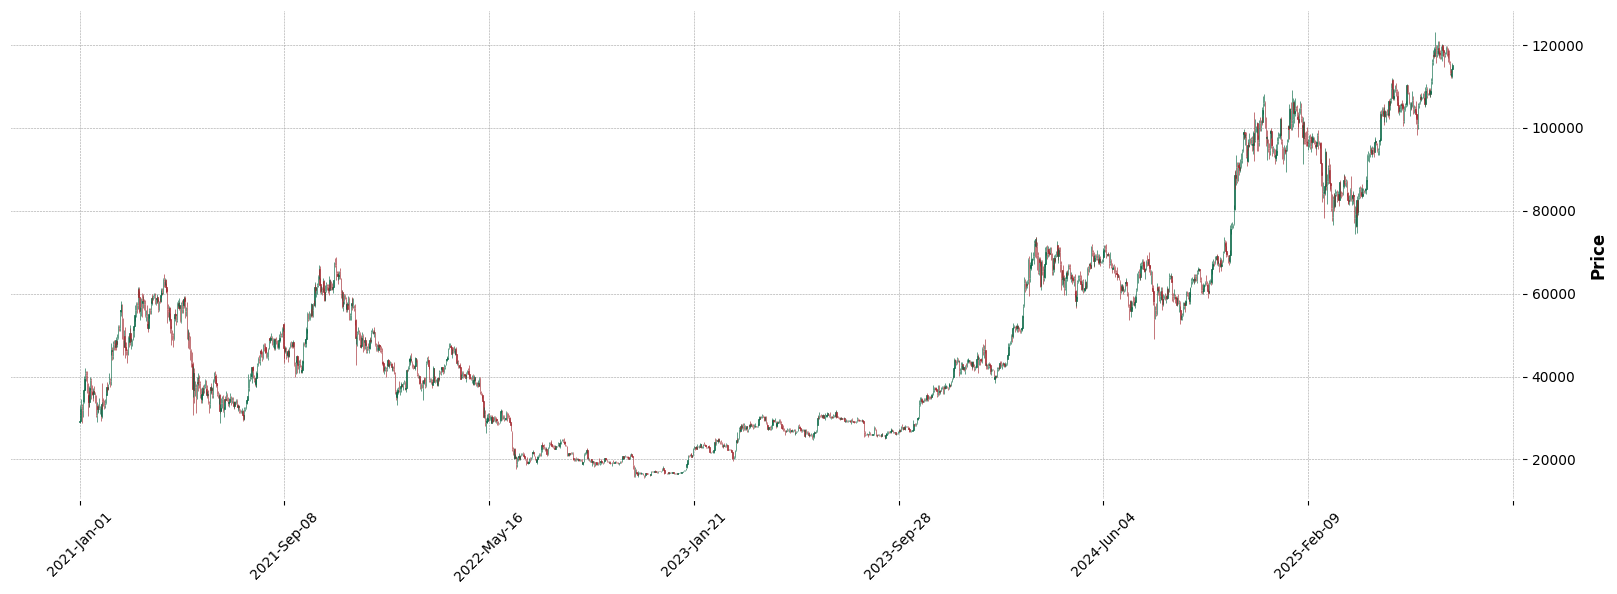

In [169]:
# Revisar en el gráfico
mpf.plot(df_plot_all, type = 'candle', volume = False, style = 'charles', figsize = (21, 7))

In [170]:
df.columns

Index(['Date', 't', 'Low', 'High'], dtype='object')

# Canales

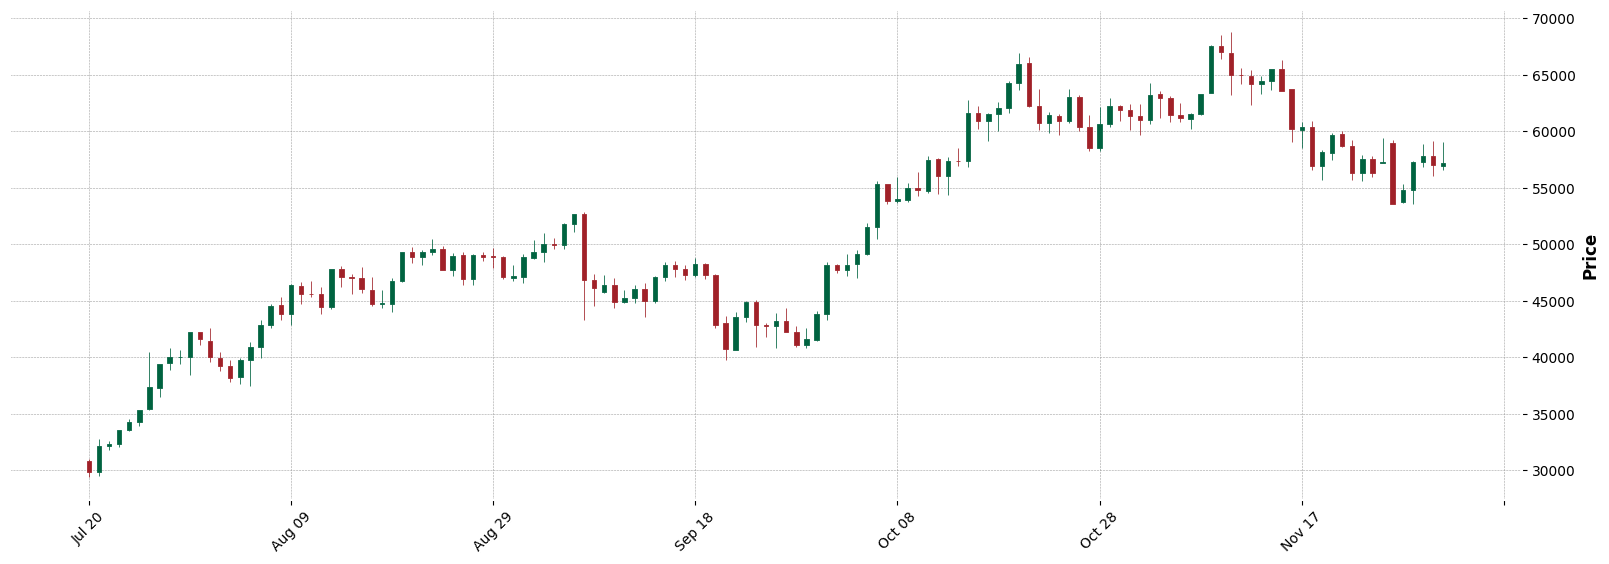

In [171]:
lista_rango_fechas = [('2021-07-20', '2021-12-01')] # Buen canal BTC
#lista_rango_fechas = [('2023-10-01', '2024-06-30')] # Mal canal BTC
#lista_rango_fechas = [('2023-10-01', '2024-02-18')] # Canal de medio nivel

for (d0, d1) in lista_rango_fechas:
    df_plot = df_data[(df_data['Date'] >= d0) & (df_data['Date'] <= d1)].copy()
    df_plot['Date'] = pd.to_datetime(df_plot['Date'])
    df_plot = df_plot.set_index('Date')

    # Crear el gráfico de velas
    mpf.plot(df_plot, type = 'candle', volume = False, style = 'charles', figsize = (21, 7))

## Encontrar un canal entre los días d0 y d1

In [172]:
# 1. generate_figure (original, para un solo trapecio)
def optimize_figure(data_points, output = True, slope_inf = 'libre', slope_sup = 'libre', paralelas = False):

    '''
    :param data_points: Nube de puntos con los campos x | y
    :type: dataframe
    '''

    # CONFIGURACION
    
    # figura libre: libre, libre, False
    # canal: libre, libre, True
    # arriba pendiente 0: 0, libre, False
    # abajo pendiente 0: libre, 0, False
    # arriba y abajo pendiente 0: 0, 0, False/True

    if (slope_inf == '0') and (slope_sup == '0'):
        variables = {'B0L': [data_points['y'].min()], 'B1L': [0], 'B0U': [data_points['y'].max()], 'B1U': [0]}
        df_variables = pd.DataFrame(variables)
        return df_variables

    data_points = data_points.reset_index(drop = True)
    
    mip_model = mip.Model()
    # Variables
    variables = {}
    for v in ['B0L', 'B1L', 'B0U', 'B1U']:
        variables[v] = mip_model.add_var(var_type = 'C', name = v)

    # Restriccion de puntos
    for i in range(len(data_points)):
        t, y = data_points['t'][i], data_points['y'][i]

        R1 = (variables['B0U'] + variables['B1U'] * t >= y)
        R2 = (variables['B0L'] + variables['B1L'] * t <= y)
        mip_model += R1
        mip_model += R2

    # Restricciones de figuras
    if slope_inf == '0':
        R3 = (variables['B1L'] == 0)
        mip_model += R3
    if slope_sup == '0':
        R4 = (variables['B1U'] == 0)
        mip_model += R4
    if paralelas:
        R5 = (variables['B1L'] == variables['B1U'])
        mip_model += R5

    # Funcion objetivo (minimizar el area del trapecio formado (altura horizontal:h)) -> Min (base_left + base_right) * h / 2 <-> Min (base_left + base_right)
    t0, tf = data_points['t'].min(), data_points['t'].max()
    base_left = variables['B0U'] + variables['B1U'] * t0 - (variables['B0L'] + variables['B1L'] * t0)
    base_right = variables['B0U'] + variables['B1U'] * tf - (variables['B0L'] + variables['B1L'] * tf)

    Z = base_left + base_right
    mip_model.objective = mip.minimize(Z)
    mip_model.verbose = 0 # Para no generar outputs de la librería mip
    status = mip_model.optimize()

    if (status == mip.OptimizationStatus.OPTIMAL) and output:
        print(f'Función objetivo: {mip_model.objective_value} óptima encontrada')
    elif (status == mip.OptimizationStatus.FEASIBLE) and output:
        print(f'Solución factible {mip_model.objective_value} encontrada (gap), mejor posible: {mip_model.objective_bound}')
    elif (status == mip.OptimizationStatus.NO_SOLUTION_FOUND) and output:
        print(f'Solución infactible, Solución RMIP: {mip_model.objective_bound}')

    if status == mip.OptimizationStatus.OPTIMAL or status == mip.OptimizationStatus.FEASIBLE:
        for v in variables:
            variables[v] = [variables[v].x]

        df_variables = pd.DataFrame(variables)
        return df_variables

    else:
        print('Error en factibilidad del modelo')
        return pd.DataFrame({})

In [173]:

#df_plot['Date'] = pd.to_datetime(df_data['Date'])
#df_data = df_data.set_index('Date')
date_0 = dt.datetime(2021, 1, 1) # Día de referencia para obtener t
df_precios = df_plot.reset_index()
df_precios['t'] = (df_precios['Date'] - date_0).dt.days # Se crea la columna t (date_0 es un día de referencia)

df_date = df_precios[['Date', 't']]
df = df_precios[['t'] + campos_modo_vela[modo_vela]]#.reset_index()
df

,t,Low,High
0,200,29360.955078,31006.187500
1,201,29526.183594,32752.326172
2,202,31745.298828,32576.400391
3,203,32057.892578,33581.550781
4,204,33424.859375,34490.390625
...,...,...,...
130,330,53668.355469,55329.257812
131,331,53576.734375,57393.843750
132,332,56792.527344,58872.878906
133,333,56057.281250,59113.402344


In [174]:
X0 = df[['t', campos_modo_vela[modo_vela][0]]].rename(columns = {campos_modo_vela[modo_vela][0]: 'y'})
X1 = df[['t', campos_modo_vela[modo_vela][1]]].rename(columns = {campos_modo_vela[modo_vela][1]: 'y'})

X = pd.concat([X0, X1], axis = 0).reset_index(drop = True)
X # Toda la nube de puntos del problema

,t,y
0,200,29360.955078
1,201,29526.183594
2,202,31745.298828
3,203,32057.892578
4,204,33424.859375
...,...,...
265,330,55329.257812
266,331,57393.843750
267,332,58872.878906
268,333,59113.402344


In [175]:
import mip
df_variables = optimize_figure(X, output = True, paralelas = True)
df_variables

Función objetivo: 48126.792421875 óptima encontrada


,B0L,B1L,B0U,B1U
0,0.0,146.804775,24063.396211,146.804775


In [176]:
# Graficar 
df_figure = X.merge(df_date, on = 't', how = 'left')
display(df_figure)

,t,y,Date
0,200,29360.955078,2021-07-20
1,201,29526.183594,2021-07-21
2,202,31745.298828,2021-07-22
3,203,32057.892578,2021-07-23
4,204,33424.859375,2021-07-24
...,...,...,...
265,330,55329.257812,2021-11-27
266,331,57393.843750,2021-11-28
267,332,58872.878906,2021-11-29
268,333,59113.402344,2021-11-30


In [177]:
# rango del canal
RC = df_variables['B0U'][0] - df_variables['B0L'][0] # KPICANALA
# pendiente del canal
SC = df_variables['B1U'][0] # KPICANALB
# Len canal
LC = df_figure['t'].max() - df_figure['t'].min() # KPICANALC

In [178]:
df_figure['U'] = df_variables['B0U'][0] + df_variables['B1U'][0] * df_figure['t']
df_figure['L'] = df_variables['B0L'][0] + df_variables['B1L'][0] * df_figure['t']
df_figure['M'] = (df_figure['U'] + df_figure['L']) / 2
df_figure

,t,y,Date,U,L,M
0,200,29360.955078,2021-07-20,53424.351289,29360.955078,41392.653184
1,201,29526.183594,2021-07-21,53571.156064,29507.759854,41539.457959
2,202,31745.298828,2021-07-22,53717.960840,29654.564629,41686.262734
3,203,32057.892578,2021-07-23,53864.765615,29801.369404,41833.067510
4,204,33424.859375,2021-07-24,54011.570391,29948.174180,41979.872285
...,...,...,...,...,...,...
265,330,55329.257812,2021-11-27,72508.972090,48445.575879,60477.273984
266,331,57393.843750,2021-11-28,72655.776865,48592.380654,60624.078760
267,332,58872.878906,2021-11-29,72802.581641,48739.185430,60770.883535
268,333,59113.402344,2021-11-30,72949.386416,48885.990205,60917.688311


In [179]:
df_figure['w'] = np.where(df_figure['y'] >= df_figure['M'], (df_figure['y'] - df_figure['M']) / (df_figure['U'] - df_figure['M']), (df_figure['y'] - df_figure['M']) / (df_figure['L'] - df_figure['M']))
df_figure

,t,y,Date,U,L,M,w
0,200,29360.955078,2021-07-20,53424.351289,29360.955078,41392.653184,1.000000
1,201,29526.183594,2021-07-21,53571.156064,29507.759854,41539.457959,0.998469
2,202,31745.298828,2021-07-22,53717.960840,29654.564629,41686.262734,0.826231
3,203,32057.892578,2021-07-23,53864.765615,29801.369404,41833.067510,0.812452
4,204,33424.859375,2021-07-24,54011.570391,29948.174180,41979.872285,0.711040
...,...,...,...,...,...,...,...
265,330,55329.257812,2021-11-27,72508.972090,48445.575879,60477.273984,0.427871
266,331,57393.843750,2021-11-28,72655.776865,48592.380654,60624.078760,0.268477
267,332,58872.878906,2021-11-29,72802.581641,48739.185430,60770.883535,0.157750
268,333,59113.402344,2021-11-30,72949.386416,48885.990205,60917.688311,0.149961


In [180]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

In [181]:
# Crear un mapa de colores personalizado (de verde claro a verde oscuro)
green_cmap = mcolors.LinearSegmentedColormap.from_list("custom_green", ["honeydew", "darkolivegreen"])  # Verde claro a verde oscuro

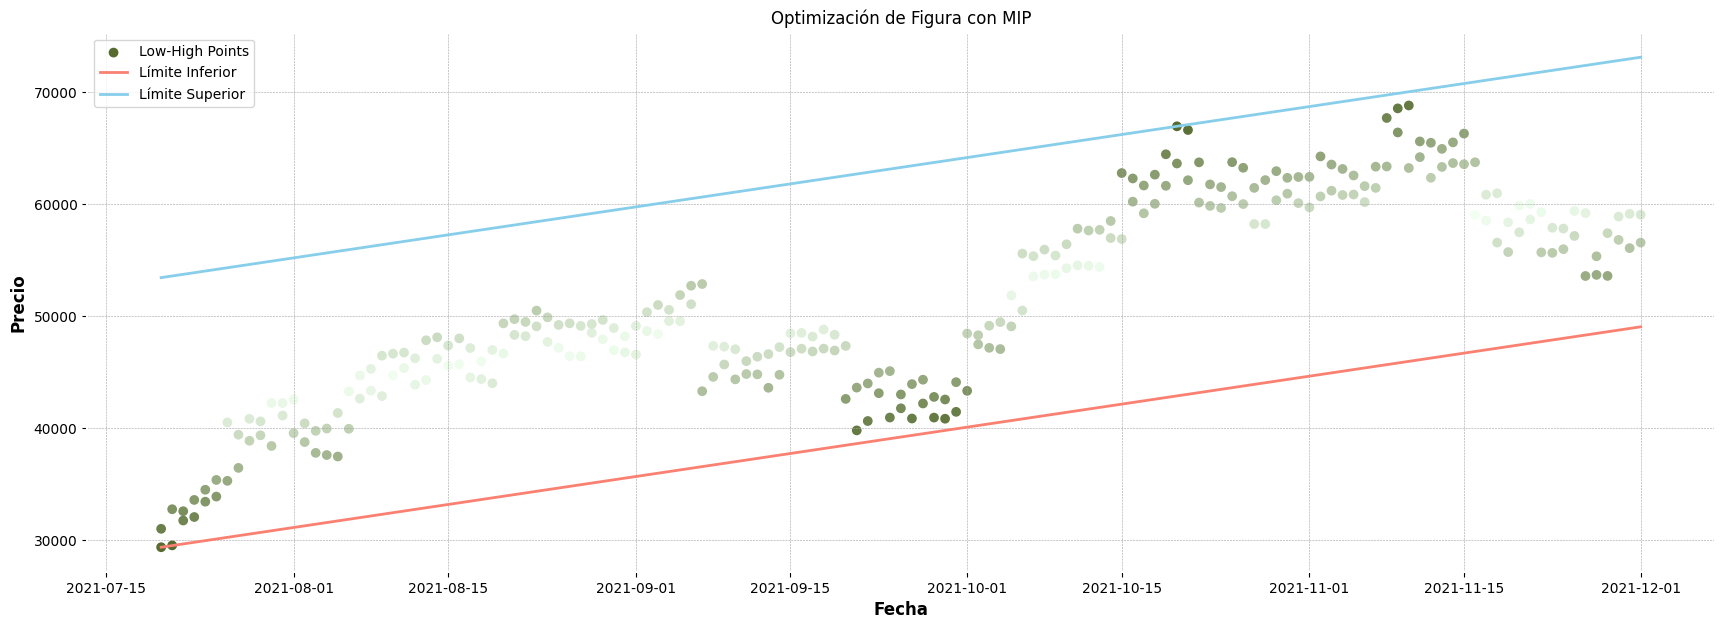

In [182]:
# Plot

plt.figure(figsize = (21, 7))
#plt.plot(df_figure['Date'], df_figure['y'], 'o', markersize = 3, label = 'data real', color = 'seagreen') # Nube de puntos
plt.scatter(df_figure['Date'], df_figure['y'], c = df_figure['w'], cmap = green_cmap, label = f"{'-'.join(campos_modo_vela[modo_vela])} Points")
plt.plot(df_figure['Date'], df_figure['L'], label = 'Límite Inferior', color = 'salmon')
plt.plot(df_figure['Date'], df_figure['U'], label = 'Límite Superior', color = 'skyblue')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.title('Optimización de Figura con MIP')
plt.legend()


## Normalizacion

In [183]:
df_figure['norm_y'] = (df_figure['y'] - df_figure['L']) / (df_figure['U'] - df_figure['L'])

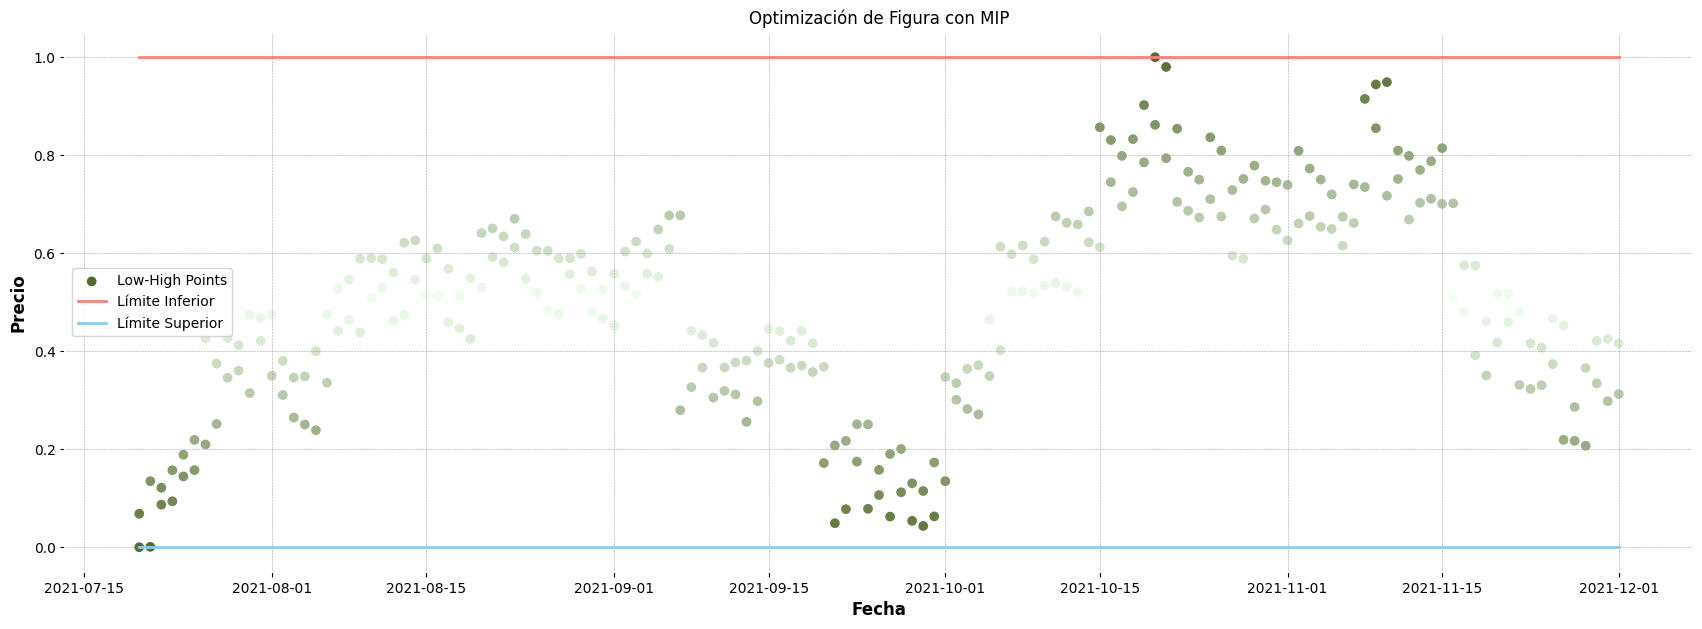

In [184]:
plt.figure(figsize = (21, 7))
#plt.plot(df_figure['Date'], df_figure['y'], 'o', markersize = 3, label = 'data real', color = 'seagreen') # Nube de puntos
plt.scatter(df_figure['Date'], df_figure['norm_y'], c = df_figure['w'], cmap = green_cmap, label = f"{'-'.join(campos_modo_vela[modo_vela])} Points")
plt.plot(df_figure['Date'], [1] * len(df_figure), label = 'Límite Inferior', color = 'salmon')
plt.plot(df_figure['Date'], [0] * len(df_figure), label = 'Límite Superior', color = 'skyblue')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.title('Optimización de Figura con MIP')
plt.legend()


In [185]:
df_figure

,t,y,Date,U,L,M,w,norm_y
0,200,29360.955078,2021-07-20,53424.351289,29360.955078,41392.653184,1.000000,0.000000
1,201,29526.183594,2021-07-21,53571.156064,29507.759854,41539.457959,0.998469,0.000766
2,202,31745.298828,2021-07-22,53717.960840,29654.564629,41686.262734,0.826231,0.086884
3,203,32057.892578,2021-07-23,53864.765615,29801.369404,41833.067510,0.812452,0.093774
4,204,33424.859375,2021-07-24,54011.570391,29948.174180,41979.872285,0.711040,0.144480
...,...,...,...,...,...,...,...,...
265,330,55329.257812,2021-11-27,72508.972090,48445.575879,60477.273984,0.427871,0.286064
266,331,57393.843750,2021-11-28,72655.776865,48592.380654,60624.078760,0.268477,0.365761
267,332,58872.878906,2021-11-29,72802.581641,48739.185430,60770.883535,0.157750,0.421125
268,333,59113.402344,2021-11-30,72949.386416,48885.990205,60917.688311,0.149961,0.425019


In [186]:
from scipy.optimize import minimize


In [187]:
# Función modelo
def y_model(x, a, k):
    return (np.sin(k * x - a) + 1) / 2

# Función de error cuadrático ponderado
def error(params, x, g, w):
    a, k = params
    y_pred = y_model(x, a, k)
    e = y_pred - g
    return np.sum(w * e**2)

In [188]:
x_data = df_figure['t']
y_data = df_figure['norm_y']
w = df_figure['w']

## Curve Fitting y elección del mejor resultado

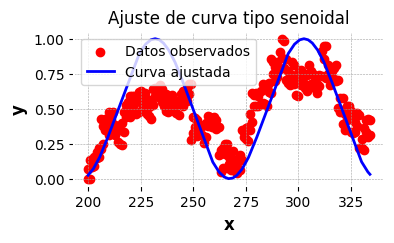

Ciclos: 1.8925
Mejor ECM: 0.0343 con a = 2.9907, k = -0.0887


,t,y,Date,U,L,M,w,norm_y,y_pred,ecw
0,200,29360.955078,2021-07-20,53424.351289,29360.955078,41392.653184,1.000000,0.000000,0.025110,0.000631
1,201,29526.183594,2021-07-21,53571.156064,29507.759854,41539.457959,0.998469,0.000766,0.040844,0.001604
2,202,31745.298828,2021-07-22,53717.960840,29654.564629,41686.262734,0.826231,0.086884,0.060192,0.000589
3,203,32057.892578,2021-07-23,53864.765615,29801.369404,41833.067510,0.812452,0.093774,0.083001,0.000094
4,204,33424.859375,2021-07-24,54011.570391,29948.174180,41979.872285,0.711040,0.144480,0.109092,0.000890
...,...,...,...,...,...,...,...,...,...,...
265,330,55329.257812,2021-11-27,72508.972090,48445.575879,60477.273984,0.427871,0.286064,0.121453,0.011594
266,331,57393.843750,2021-11-28,72655.776865,48592.380654,60624.078760,0.268477,0.365761,0.093993,0.019829
267,332,58872.878906,2021-11-29,72802.581641,48739.185430,60770.883535,0.157750,0.421125,0.069729,0.019479
268,333,59113.402344,2021-11-30,72949.386416,48885.990205,60917.688311,0.149961,0.425019,0.048851,0.021220


In [189]:
delta = x_data.max() - x_data.min() # distancia del rango horizontal
best_ecm = float('inf')
for i in range(1, 20):
    k0 = 2 * np.pi / (delta / i)
    #print(k0)
    # Valores iniciales de a y k
    initial_guess = [0, k0]

    # Minimización
    result = minimize(error, initial_guess, args=(x_data, y_data, w))

    # Resultados
    a_opt, k_opt = result.x
    #print(f"Parámetros óptimos encontrados: a = {a_opt:.4f}, k = {k_opt:.4f}")
    
    df_figure = df_figure.copy()
    df_figure['y_pred'] = y_model(x_data, a_opt, k_opt)
    df_figure['ecw'] = w * (df_figure['y_pred'] - df_figure['norm_y'])**2
    ecm = df_figure['ecw'].sum() / df_figure['w'].sum()
    if ecm < best_ecm:
        best_ecm = ecm
        best_a = a_opt
        best_k = k_opt
        df_best = df_figure.copy()

# Graficar mejor resultado
x_plot = np.linspace(x_data.min(), x_data.max(), len(y_data))
y_fit = y_model(x_plot, best_a, best_k)

plt.figure(figsize=(4, 2))
plt.scatter(x_data, y_data, label='Datos observados', color='red')
plt.plot(x_plot, y_fit, label='Curva ajustada', color='blue')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Ajuste de curva tipo senoidal')
plt.grid(True)
plt.show()


ciclos = abs(delta * best_k / (2 * np.pi)) # KPICANAL1
print(f"Ciclos: {ciclos:.4f}")
print(f"Mejor ECM: {best_ecm:.4f} con a = {best_a:.4f}, k = {best_k:.4f}")

best_ecm # KPICANAL2
df_best


## Equilibrio del canal

In [190]:
df_figure = df_figure.sort_values(by = 't').reset_index(drop = True)
df_figure_t = df_figure[['Date', 't', 'y', 'norm_y', 'w', 'U', 'L', 'M', 'y_pred']].groupby('Date').mean().reset_index() # sys.exit('Promediar en cada día (t) las métricas y, U, L, M, w, norm y, y_pred')
display(df_figure_t)

,Date,t,y,norm_y,w,U,L,M,y_pred
0,2021-07-20,200.0,30183.571289,0.034185,0.931629,53424.351289,29360.955078,41392.653184,0.121639
1,2021-07-21,201.0,31139.254883,0.067800,0.864400,53571.156064,29507.759854,41539.457959,0.310025
2,2021-07-22,202.0,32160.849609,0.104153,0.791693,53717.960840,29654.564629,41686.262734,0.998879
3,2021-07-23,203.0,32819.721680,0.125433,0.749133,53864.765615,29801.369404,41833.067510,0.373491
4,2021-07-24,204.0,33957.625000,0.166620,0.666759,54011.570391,29948.174180,41979.872285,0.081377
...,...,...,...,...,...,...,...,...,...
130,2021-11-27,330.0,54498.806641,0.251553,0.496893,72508.972090,48445.575879,60477.273984,0.040822
131,2021-11-28,331.0,55485.289062,0.286448,0.427104,72655.776865,48592.380654,60624.078760,0.833309
132,2021-11-29,332.0,57832.703125,0.377898,0.244203,72802.581641,48739.185430,60770.883535,0.747730
133,2021-11-30,333.0,57585.341797,0.361518,0.276964,72949.386416,48885.990205,60917.688311,0.009534


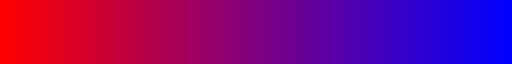

In [191]:
# de rojo a azul
red_blue_cmap = mcolors.LinearSegmentedColormap.from_list("red_blue", ["red", "blue"])  # Rojo a azul
red_blue_cmap

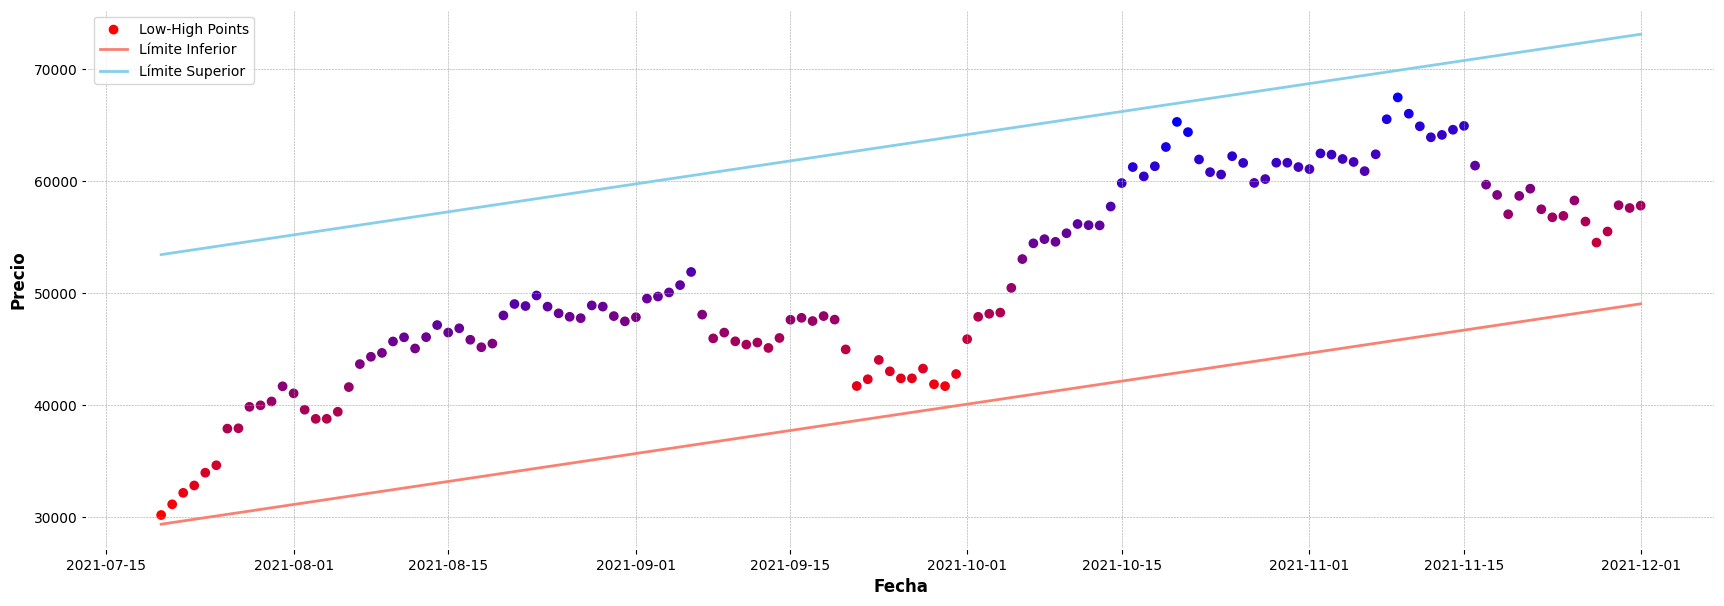

In [192]:
df_figure_t['s'] = np.where(df_figure_t['y'] >= df_figure_t['M'], (df_figure_t['y'] - df_figure_t['M']) / (df_figure_t['U'] - df_figure_t['M']), - (df_figure_t['y'] - df_figure_t['M']) / (df_figure_t['L'] - df_figure_t['M']))
# a diferencia de w, que vale 1 en los extremos (inf y sup) y 0 en el centro, s vale 1 en sup, 0 en el centro y -1 en inf

# Plot

plt.figure(figsize = (21, 7))
plt.scatter(df_figure_t['Date'], df_figure_t['y'], c = df_figure_t['s'], cmap = red_blue_cmap, label = f"{'-'.join(campos_modo_vela[modo_vela])} Points")
plt.plot(df_figure_t['Date'], df_figure_t['L'], label = 'Límite Inferior', color = 'salmon')
plt.plot(df_figure_t['Date'], df_figure_t['U'], label = 'Límite Superior', color = 'skyblue')
plt.xlabel('Fecha')
plt.ylabel('Precio')
#plt.title('Optimización de Figura con MIP')
plt.legend()

In [193]:
df_figure_t = df_figure_t.sort_values(by = 't')

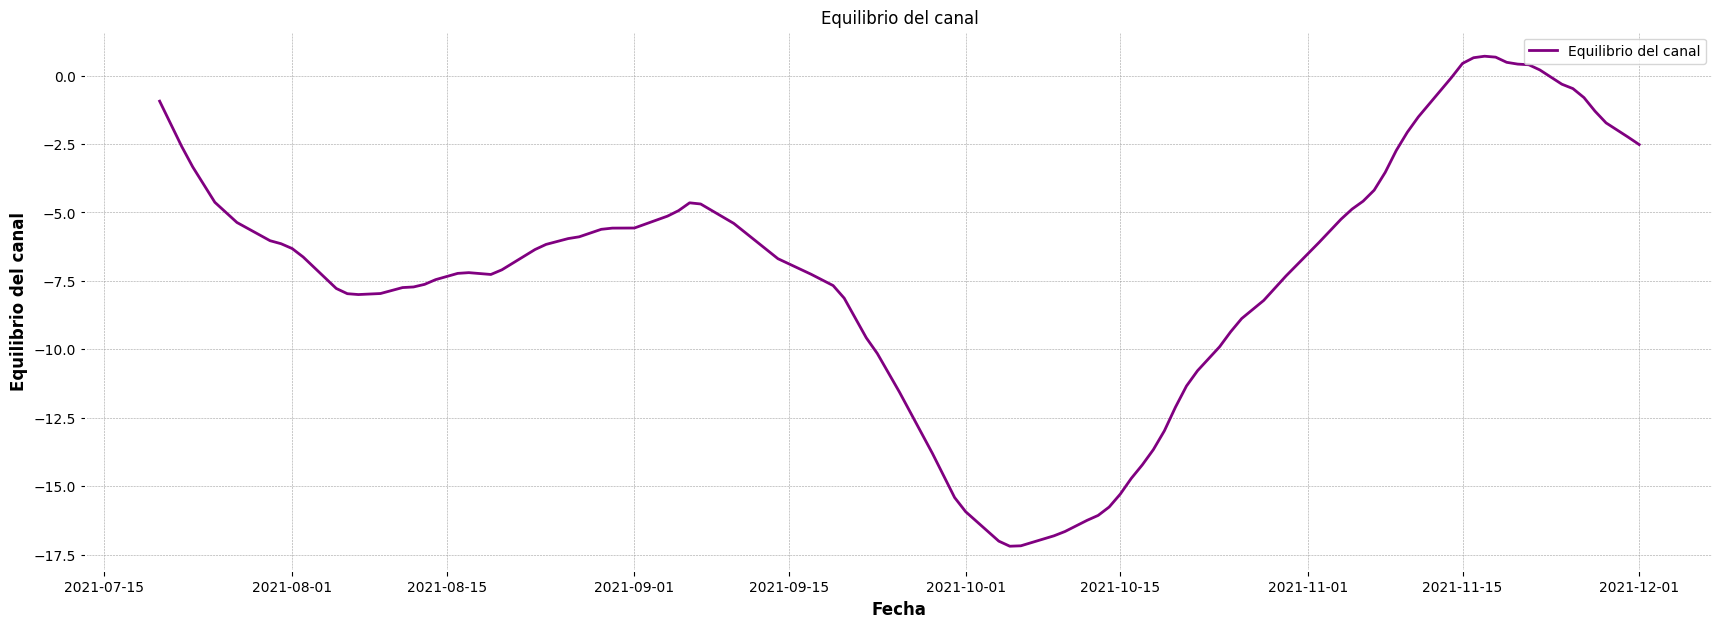

In [194]:
# Este es el valor que adicionarán sucesivamente, se graficará como equilibrio del canal
df_figure_t['s_cum'] = df_figure_t['s'].cumsum()
plt.figure(figsize = (21, 7))
plt.plot(df_figure_t['Date'], df_figure_t['s_cum'], label = 'Equilibrio del canal', color = 'purple')
plt.xlabel('Fecha')
plt.ylabel('Equilibrio del canal')
plt.title('Equilibrio del canal')
plt.legend()
plt.show()

In [195]:
Rango_s_cum = (df_figure_t['s_cum'].max() - df_figure_t['s_cum'].min()) / len(df_figure_t) # KPICANAL3
Rango_s_cum

0.13264637744362573

## Distribución y n-momentos del valor s (media, varianza, kurtosis...)

In [198]:
df_figure['s'] = np.where(df_figure['y'] >= df_figure['M'], (df_figure['y'] - df_figure['M']) / (df_figure['U'] - df_figure['M']), - (df_figure['y'] - df_figure['M']) / (df_figure['L'] - df_figure['M'])) # sys.exit('Promediar en cada día (t) las métricas y, U, L, M, w, norm y, y_pred')
df_figure

,t,y,Date,U,L,M,w,norm_y,y_pred,ecw,s
0,200,29360.955078,2021-07-20,53424.351289,29360.955078,41392.653184,1.000000,0.000000,0.121639,0.014796,-1.000000
1,200,31006.187500,2021-07-20,53424.351289,29360.955078,41392.653184,0.863259,0.068371,0.121639,0.002450,-0.863259
2,201,29526.183594,2021-07-21,53571.156064,29507.759854,41539.457959,0.998469,0.000766,0.310025,0.095495,-0.998469
3,201,32752.326172,2021-07-21,53571.156064,29507.759854,41539.457959,0.730332,0.134834,0.310025,0.022415,-0.730332
4,202,31745.298828,2021-07-22,53717.960840,29654.564629,41686.262734,0.826231,0.086884,0.998879,0.687205,-0.826231
...,...,...,...,...,...,...,...,...,...,...,...
265,332,56792.527344,2021-11-29,72802.581641,48739.185430,60770.883535,0.330656,0.334672,0.747730,0.056416,-0.330656
266,333,59113.402344,2021-11-30,72949.386416,48885.990205,60917.688311,0.149961,0.425019,0.009534,0.025888,-0.149961
267,333,56057.281250,2021-11-30,72949.386416,48885.990205,60917.688311,0.403967,0.298017,0.009534,0.033619,-0.403967
268,334,56553.082031,2021-12-01,73096.191191,49032.794980,61064.493086,0.374960,0.312520,0.563416,0.023603,-0.374960


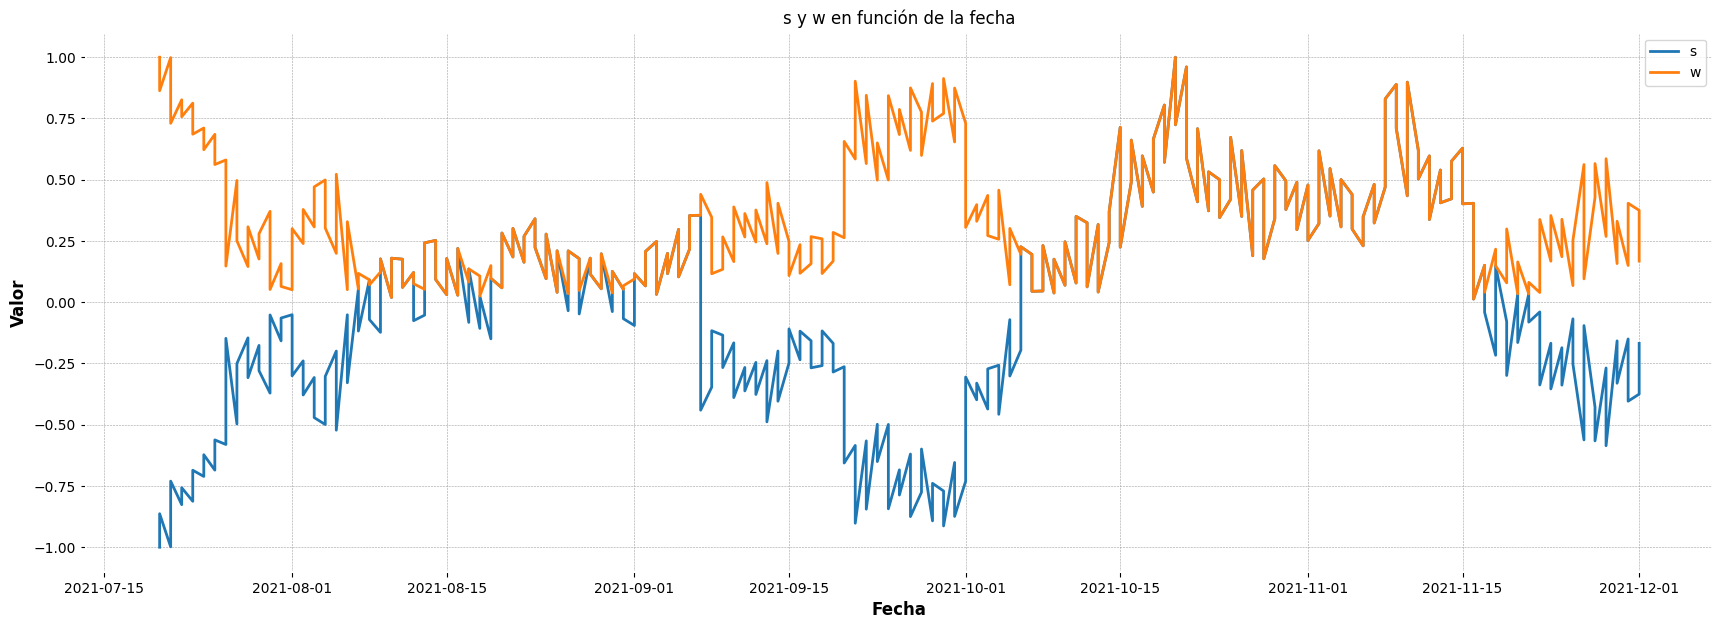

In [ ]:
# Plot s y w en función de Date (w = abs(s))
plt.figure(figsize = (21, 7))
plt.plot(df_figure['Date'], df_figure['s'], label = f"s")
plt.plot(df_figure['Date'], df_figure['w'], label = f"w")
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.title('s y w en función de la fecha')
plt.legend()
plt.show()

In [200]:
from scipy.stats import norm

In [201]:
def momento_k(datos, k):
    """
    Calcula el k-ésimo momento central de una serie de datos.
    
    Parámetros:
        datos (array-like): Lista o arreglo de datos numéricos.
        k (int): Orden del momento (1 = media, 2 = varianza, 3 = asimetría, 4 = curtosis).
        
    Retorna:
        float: Valor del momento k-ésimo.
    """
    datos = np.array(datos)
    media = np.mean(datos)
    
    if k == 1:
        return media
    else:
        return np.mean((datos - media)**k)
    

Momento 1 (Media de s): -0.0187
Momento 2 (Varianza de s): 0.1795
Momento 3 (Asimetría de s): -0.0110
Momento 4 (Curtosis de s): 0.0806


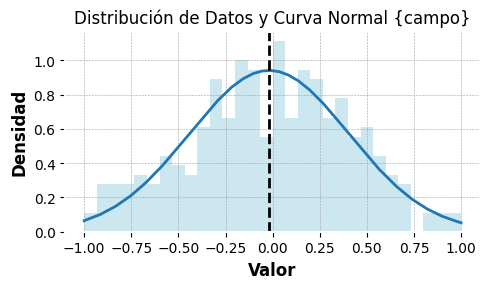

Momento 1 (Media de w): 0.3470
Momento 2 (Varianza de w): 0.0595
Momento 3 (Asimetría de w): 0.0106
Momento 4 (Curtosis de w): 0.0096


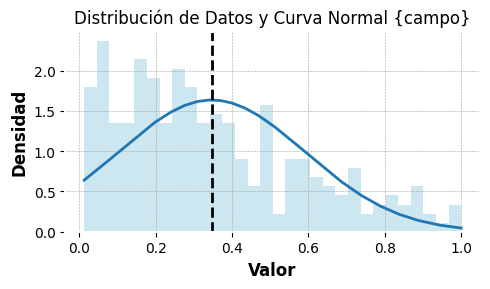

In [ ]:
for campo in ['s', 'w']:
    serie = df_figure[campo].values
    momento_1 = momento_k(serie, 1)  # Media
    print(f"Momento 1 (Media de {campo}): {momento_1:.4f}") # KPICANAL4 s y w ...para w, que tan hacia los extremos del canal se encuentran los datos
    momento_2 = momento_k(serie, 2)  # Varianza
    print(f"Momento 2 (Varianza de {campo}): {momento_2:.4f}") # KPICANAL5 s y w
    momento_3 = momento_k(serie, 3)  # Asimetría
    print(f"Momento 3 (Asimetría de {campo}): {momento_3:.4f}") # KPICANAL6 s y w
    momento_4 = momento_k(serie, 4)  # Curtosis
    print(f"Momento 4 (Curtosis de {campo}): {momento_4:.4f}") # KPICANAL7 s y w
    
    # Graficar los datos como puntos
    plt.figure(figsize=(5, 3))
    plt.hist(serie, bins=30, density=True, alpha=0.6, color='lightblue', label='Datos')

    # Distribución normal teórica con misma media y varianza
    x = np.linspace(min(serie), max(serie), 300)
    pdf_normal = norm.pdf(x, loc = momento_1, scale = np.sqrt(momento_2))
    plt.plot(x, pdf_normal, lw = 2, label='Distribución normal (misma media y varianza)')

    # Añadir momentos al gráfico
    plt.axvline(momento_1, color = 'k', linestyle = '--', label = f"Media = {momento_1:.2f}")
    plt.title("Distribución de Datos y Curva Normal {campo}")
    plt.xlabel("Valor")
    plt.ylabel("Densidad")
    #plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    

## Ratio Area sobre y bajo

In [ ]:
df_figure_t['sobre_area'] = 1 - df_figure_t['norm_y']  # Área sobre la línea de equilibrio (1 - norm_y)
df_figure_t['bajo_area'] = df_figure_t['norm_y']  # Área bajo la línea de equilibrio (norm_y)

area_sobre, area_bajo = df_figure_t['sobre_area'].sum(), df_figure_t['bajo_area'].sum()
print(f"Área sobre la línea de equilibrio: {area_sobre:.4f}")
print(f"Área bajo la línea de equilibrio: {area_bajo:.4f}")

# ratiode areas

r_areas = min(area_sobre, area_bajo) / max(area_sobre, area_bajo)
r_areas # KPICANAL8

In [ ]:
df_figure_t

# N - Tendencias

In [203]:
date_0 = dt.datetime(2021, 1, 1) # Día de referencia para obtener t
df_precios = df_data.reset_index()
df_precios['t'] = (df_precios['Date'] - date_0).dt.days # Se crea la columna t (date_0 es un día de referencia)

df_date = df_precios[['Date', 't']]
df = df_precios[['t'] + campos_modo_vela[modo_vela]].reset_index()
df

,index,t,Low,High
0,0,0,28803.585938,29600.626953
1,1,1,29091.181641,33155.117188
2,2,2,32052.316406,34608.558594
3,3,3,28722.755859,33440.218750
4,4,4,30221.187500,34437.589844
...,...,...,...,...
1672,1672,1672,115505.218750,118919.984375
1673,1673,1673,112724.445312,116060.773438
1674,1674,1674,112005.765625,114021.601562
1675,1675,1675,111943.804688,114747.421875


In [204]:
X0 = df[['t', campos_modo_vela[modo_vela][0]]].rename(columns = {campos_modo_vela[modo_vela][0]: 'y'})
X1 = df[['t', campos_modo_vela[modo_vela][1]]].rename(columns = {campos_modo_vela[modo_vela][1]: 'y'})

X = pd.concat([X0, X1], axis = 0).reset_index(drop = True)
X # Toda la nube de puntos del problema

,t,y
0,0,28803.585938
1,1,29091.181641
2,2,32052.316406
3,3,28722.755859
4,4,30221.187500
...,...,...
3349,1672,118919.984375
3350,1673,116060.773438
3351,1674,114021.601562
3352,1675,114747.421875


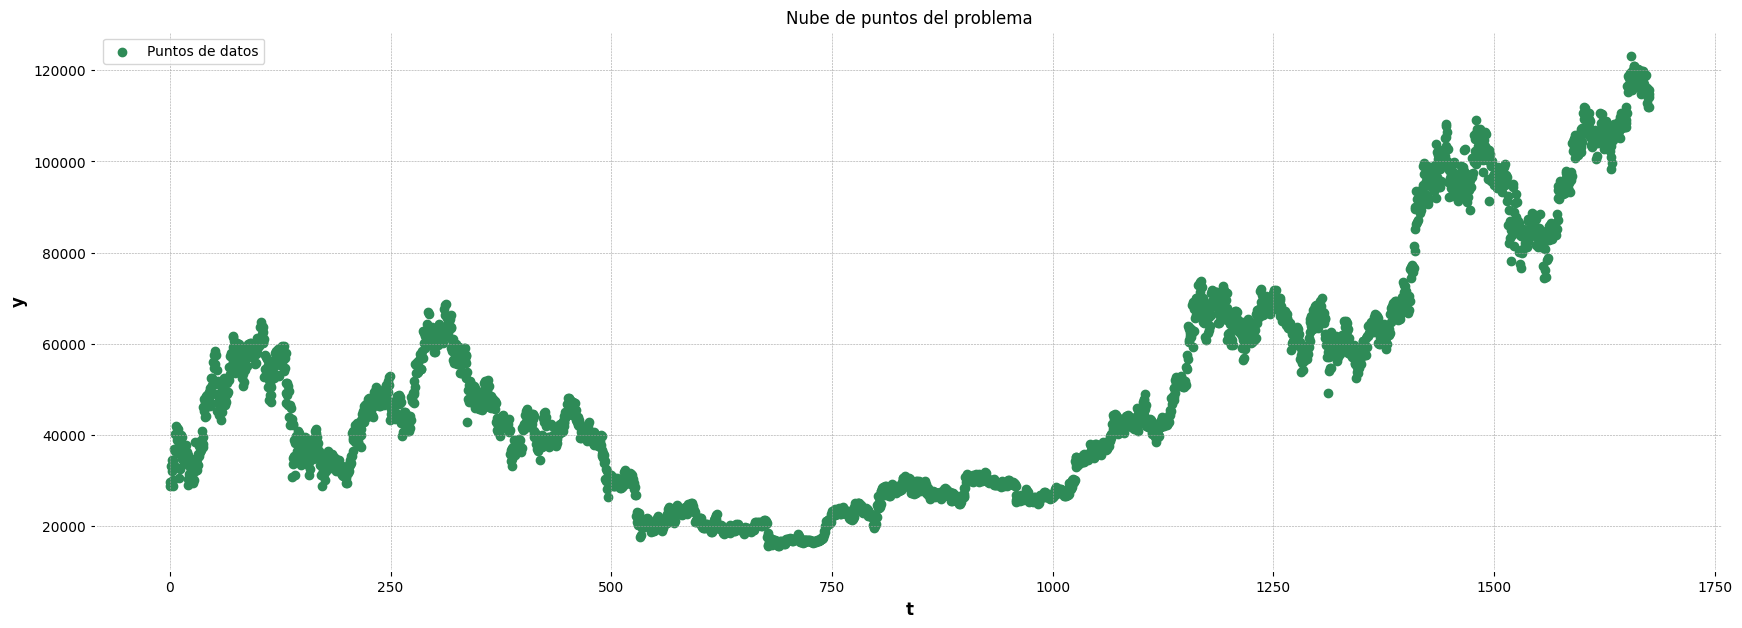

In [205]:
# Graficar X
plt.figure(figsize = (21, 7))
plt.scatter(X['t'], X['y'], label = 'Puntos de datos', color = 'seagreen')
plt.xlabel('t')
plt.ylabel('y')
plt.title('Nube de puntos del problema')
plt.legend()
plt.show()

## Revisión para una partición en dos espacios temporales

In [206]:
from sklearn.linear_model import LinearRegression

In [207]:
X['t'].min(), X['t'].max()

(0, 1676)

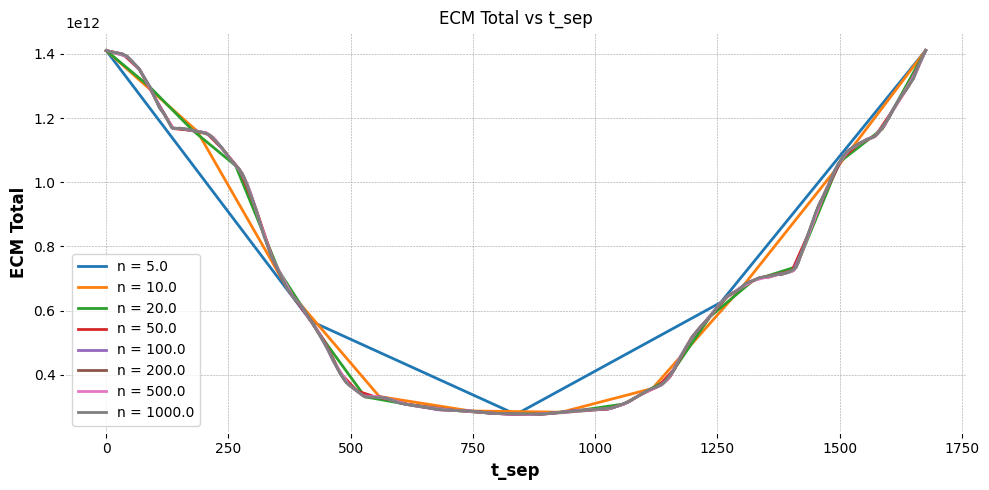

In [213]:
df_ecms = pd.DataFrame(columns = ['t_sep', 'ECM_total'])
plotear = False
t_min, t_max = X['t'].min(), X['t'].max()
n = 1000

for n in [5, 10, 20, 50, 100, 200, 500, 1000]: # Número de cortes a evaluar
#for n in [5, 10, 20]: # Número de cortes a evaluar
    for k in range(n): # Sin tomar los extremos explícitos

        #print('k', k)
        t_sep = t_min + (t_max - t_min) * k / (n - 1) #(k + 1) / (n + 1)
        #print('X')
        X0 = X[X['t'] <= t_sep].reset_index(drop = True)
        X1 = X[X['t'] > t_sep].reset_index(drop = True)

        # Regresion lineal en X0
        # Variables
        X_data = X0[['t']]  # sklearn espera X como matriz (2D)
        y_data = X0['y']

        # Crear y ajustar el modelo
        model0 = LinearRegression()
        model0.fit(X_data, y_data)

        # Predicción
        y_pred0 = model0.predict(X_data)

        if len(X1) > 0:
            X_data = X1[['t']]  # sklearn espera X como matriz (2D)
            y_data = X1['y']

            # Crear y ajustar el modelo
            model1 = LinearRegression()
            model1.fit(X_data, y_data)

            # Predicción
            y_pred1 = model1.predict(X_data)
        
        if plotear:
            # Grafico
            plt.figure(figsize=(10, 5))

            # Graficar puntos
            plt.scatter(X0['t'], X0['y'], alpha=0.4, label='Datos X0', color='green')
            plt.scatter(X1['t'], X1['y'], alpha=0.4, label='Datos X1', color='blue')

            # Línea de regresión X0
            plt.plot(X0['t'], y_pred0, color='darkgreen', linewidth=2, label='Regresión X0')

            # Línea de regresión X1
            if len(X1) > 0:
                plt.plot(X1['t'], y_pred1, color='darkblue', linewidth=2, label='Regresión X1')

            # Anotar coeficientes
            b0_0 = model0.intercept_
            b1_0 = model0.coef_[0]
            if len(X1) > 0:
                b0_1 = model1.intercept_
                b1_1 = model1.coef_[0]
            else:
                b0_1 = None
                b1_1 = None
    
            print(f'B0_0: {b0_0}, B1_0: {b1_0}, B0_1: {b0_1}, B1_1: {b1_1}')

            plt.text(X0['t'].min(), y_pred0.min(), f'B0 = {b0_0:.2f}\nB1 = {b1_0:.2f}', 
                    fontsize=9, color='darkgreen', verticalalignment='bottom')

            if len(X1) > 0:
                plt.text(X1['t'].min(), y_pred1.min(), f'B0 = {b0_1:.2f}\nB1 = {b1_1:.2f}', 
                        fontsize=9, color='darkblue', verticalalignment='bottom')


            # Línea vertical del corte t_sep
            plt.axvline(t_sep, color='gray', linestyle='--', label=f'Corte en t = {t_sep}')

            # Detalles del gráfico
            plt.xlabel('t')
            plt.ylabel('y')
            plt.title('Regresiones Lineales por Tramo')
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()
        
        if len(X1) > 0:
            
            ECM_total = np.sum((X0['y'] - y_pred0) ** 2) + np.sum((X1['y'] - y_pred1) ** 2)
        else:
            ECM_total = np.sum((X0['y'] - y_pred0) ** 2)
        #print(f'ECM total: {ECM_total:.4f}')
        
        df_ecms_new = pd.DataFrame({'t_sep': [t_sep], 'ECM_total': [ECM_total], 'n': [n]})
        df_ecms = pd.concat([df_ecms, df_ecms_new])
    
#display(df_ecms)

# Graficar ECMs
plt.figure(figsize=(10, 5))
for n in df_ecms['n'].unique():
    df_n = df_ecms[df_ecms['n'] == n]
    plt.plot(df_n['t_sep'], df_n['ECM_total'], linestyle='-', label=f'n = {n}')
plt.xlabel('t_sep')
plt.ylabel('ECM Total')
plt.title('ECM Total vs t_sep')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()
    
    
    

## Algorítmo de tendencias

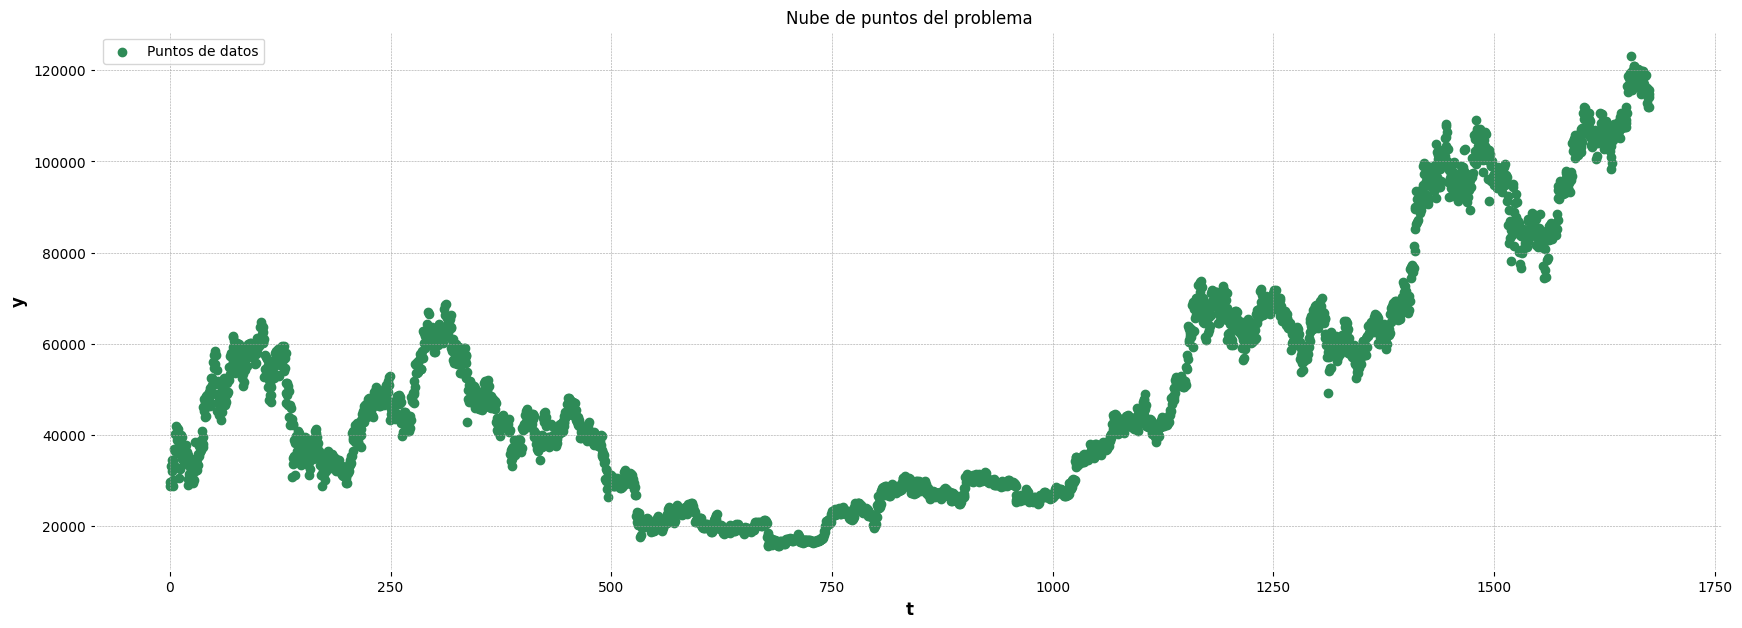

In [214]:
# Graficar X
plt.figure(figsize = (21, 7))
plt.scatter(X['t'], X['y'], label = 'Puntos de datos', color = 'seagreen')
plt.xlabel('t')
plt.ylabel('y')
plt.title('Nube de puntos del problema')
plt.legend()
plt.show()

In [227]:
def generar_tendencia(X, t_extremos = []):
    if len(t_extremos) == 2:
        X = X[(X['t'] >= t_extremos[0]) & (X['t'] <= t_extremos[1])].reset_index(drop = True) # Se acota
        
    X_data = X[['t']]  # sklearn espera X como matriz (2D)
    y_data = X['y']

    # Crear y ajustar el modelo
    model = LinearRegression()
    model.fit(X_data, y_data)

    # Predicción
    b0 = model.intercept_
    b1 = model.coef_[0]
    return b0, b1

{'B_0': 0, 'B_1': 559, 'B_2': 1117, 'B_3': 1676}
p 1 [0, 559]
p 2 [559, 1117]
p 3 [1117, 1676]
['B_1', 'B_2']


SystemExit: 

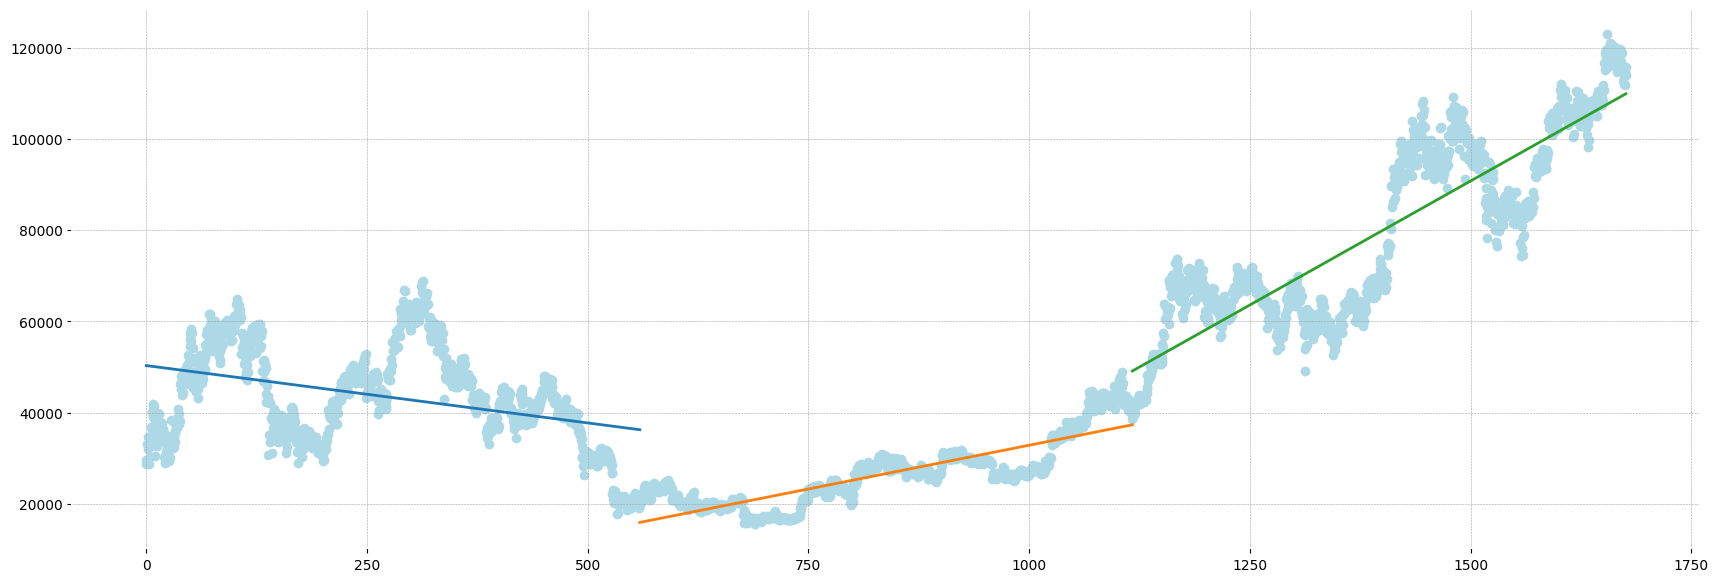

In [ ]:
particiones = 3

# Inicialización
puntos_iniciales = np.linspace(X['t'].min(), X['t'].max(), particiones + 1)  # Excluir el primer y último punto, ya que son fijos (inicial y final)

# Los puntos se llevan a un diccionario de barreras
barreras = {}
for i in range(particiones + 1):
    barreras[f'B_{i}'] = round(puntos_iniciales[i])
print(barreras)

# Cálculo inicial de tendencias

betas, extremos = {}, {}
for p in range(1, particiones + 1):
    t_extremos = [barreras[f'B_{p - 1}'], barreras[f'B_{p}']]
    print('p', p, t_extremos)
    betas[p] = generar_tendencia(X, t_extremos)
    extremos[p] = t_extremos

# Graficar (solo gráfico inicial de prueba)
plt.figure(figsize = (21, 7))
plt.scatter(X['t'], X['y'], label = 'Puntos de datos', color = 'lightblue')
for p in range(1, particiones + 1):
    t_extremos = extremos[p]
    b0, b1 = betas[p]
    t_values = np.linspace(t_extremos[0], t_extremos[1], 100)
    y_values = b0 + b1 * t_values
    plt.plot(t_values, y_values, label = f'Tendencia {p}', linewidth = 2)
    

barreras_moviles = list(barreras.keys())[1:-1] # Inicialmente, mover todo lo que no es extremo izq o der
print(barreras_moviles)
# Inicio iteraciones
while True:
    
    
    # Actualizar barreras_moviles (que barreras se pueden mover en la siguiente iteración) 
    sys.exit('Continuar aqui 250806')



# Otros

In [ ]:
sys.exit('Otros de aquí hacia abajo')

In [ ]:
valor.ajustar_data(False)
df_rendimientos = valor.adj_data
df_rendimientos = df_rendimientos[df_rendimientos.Date >= "2020-01-01"].reset_index(drop=True) # small batch de prueba
df_rendimientos

In [ ]:
# graficar
import matplotlib.pyplot as plt
plt.figure(figsize = (20, 10))
plt.plot(df_rendimientos['Date'], df_rendimientos['Open'])
plt.plot(df_rendimientos['Date'], df_rendimientos['Close'])
plt.show()

In [ ]:
sys.exit()

# Problema de las áreas

In [ ]:
campos_modo_vela = {'area': ['Open', 'Close'], 'extremos': ['Low', 'High']}
modo_vela = 'area' # area o extremos


df = df_rendimientos[['t'] + campos_modo_vela[modo_vela]].reset_index()
df_date = df[['Date', 't']]
df

In [ ]:
X0 = df[['t', campos_modo_vela[modo_vela][0]]].rename(columns = {campos_modo_vela[modo_vela][0]: 'y'})
X1 = df[['t', campos_modo_vela[modo_vela][1]]].rename(columns = {campos_modo_vela[modo_vela][1]: 'y'})

X = pd.concat([X0, X1], axis = 0)
#X = X.rename(columns = {'t': 'x'}).reset_index(drop = True)
X # Toda la nube de puntos del problema

In [ ]:
def crear_dic_t_incial(df, K):
    t_min, t_max = df['t'].min(), df['t'].max()
    dic_t = {}
    for k in range(K + 1):
        t = t_min + k * (t_max - t_min) / K
        dic_t[k] = round(t)
    return dic_t

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# Graficar los datos en X, pinta de un color distinto según k_grupo

def graficar(X, K, df_date, dic_puntos = {}, dic_t = {}, titulo = ""):
    
    X = X.merge(df_date, on = 't', how = 'left')
    
    if len(dic_t) > 0:
        X['k'] = X['t'].apply(lambda t: sum([t >= dic_t[k] for k in range(K)])) # Cuantas veces supera límites inferiores = Grupo
        X = X.sort_values(by = 't').reset_index(drop = True)
        
    plt.figure(figsize = (10, 5))
    grupos = X['k'].unique()
    for k in grupos:
        X_k = X[X['k'] == k]
        plt.plot(X_k['Date'], X_k['y'], 'o', label = f'Grupo {k}', c = plt.cm.tab20(k), markersize = 2) # markersize: tamaño de los puntos
    
        if k not in dic_puntos:
            continue    
        B0L, B1L, B0U, B1U = dic_puntos[k]['B0L'], dic_puntos[k]['B1L'], dic_puntos[k]['B0U'], dic_puntos[k]['B1U']
        plt.plot([X_k['Date'].min(), X_k['Date'].max()], [B0L + B1L * X_k['t'].min(), B0L + B1L * X_k['t'].max()], c = 'r')
        plt.plot([X_k['Date'].min(), X_k['Date'].max()], [B0U + B1U * X_k['t'].min(), B0U + B1U * X_k['t'].max()], c = 'g')
    
    if titulo != "":
        plt.title(titulo)
    plt.show()

In [ ]:
import mip
# 1. generate_figure
def generate_all_figure(data_points, dic_t, gamma, output = True, slope_inf = 'libre', slope_sup = 'libre', paralelas = False, segmentos_conjuntos = True):

    '''
    :param data_points: Nube de puntos con los campos k | x | y, donde k es el grupo al que pertenece
    :param dic_t: Diccionario con los límites de los grupos
    :param gamma: Peso de las holguras
    :type: dataframe
    '''

    # CONFIGURACION
    
    # figura libre: libre, libre, False
    # canal: libre, libre, True
    # arriba pendiente 0: 0, libre, False
    # abajo pendiente 0: libre, 0, False
    # arriba y abajo pendiente 0: 0, 0, False/True

    output_vars = False
    data_points = data_points.reset_index(drop = True)
    
    grupos = data_points['k'].unique()
    
    mip_model = mip.Model()
    # Variables
    variables = {}
    for k in grupos:
        for v in ['B0L', 'B1L', 'B0U', 'B1U', 'HU', 'HL']: # HU & HL son las holguras en los grupos
            if v in ['HU', 'HL']:
                variables[f'G{k}_{v}'] = mip_model.add_var(var_type = 'C', name = f'G{k}_{v}') # C: Continuas >= 0
            else:
                variables[f'G{k}_{v}'] = mip_model.add_var(var_type = 'C', name = f'G{k}_{v}', lb = - float('inf')) 
        
    # Restriccion de puntos
    for k in grupos:
        data_k = data_points[data_points['k'] == k].reset_index(drop = True)
        for i in range(len(data_k)):
            t, y = data_k['t'][i], data_k['y'][i]
            #y = data_k['y'][i]
            
            variables[f'G{k}_HU_{i}'] = mip_model.add_var(var_type = 'C', name = f'G{k}_HU_{i}') # C: Continuas
            variables[f'G{k}_HL_{i}'] = mip_model.add_var(var_type = 'C', name = f'G{k}_HL_{i}') # C: Continuas

            R1 = (variables[f'G{k}_B0U'] + variables[f'G{k}_B1U'] * t >= y - variables[f'G{k}_HU_{i}']) # Se incluyen las holguras
            R2 = (variables[f'G{k}_B0L'] + variables[f'G{k}_B1L'] * t <= y + variables[f'G{k}_HL_{i}'])
            
            # independiente de las holguras, la recta superior debeestar siempre sobre la inferior
            R3 = (variables[f'G{k}_B0U'] + variables[f'G{k}_B1U'] * t >= variables[f'G{k}_B0L'] + variables[f'G{k}_B1L'] * t)
            
            mip_model += R1
            mip_model += R2
            mip_model += R3


    # Restricciones de figuras
    if slope_inf == '0':
        for k in grupos:
            R4A = (variables[f'G{k}_B1L'] == 0)
            mip_model += R4A
    if slope_sup == '0':
        for k in grupos:
            R4B = (variables[f'G{k}_B1U'] == 0)
            mip_model += R4B
    if paralelas:
        for k in grupos:
            R4C = (variables[f'G{k}_B1L'] == variables[f'G{k}_B1U'])
            mip_model += R4C
            
    # Restricciones de segmentos conjuntos
    
    #sys.exit()
    for k in grupos:
        if not segmentos_conjuntos:
            break
        if k == max(grupos): # EL último límite no es contemplado
            break
        
        R5 = (variables[f'G{k}_B0L'] + variables[f'G{k}_B1L'] * dic_t[k] == variables[f'G{k + 1}_B0L'] + variables[f'G{k + 1}_B1L'] * dic_t[k])
        mip_model += R5
        R6 = (variables[f'G{k}_B0U'] + variables[f'G{k}_B1U'] * dic_t[k] == variables[f'G{k + 1}_B0U'] + variables[f'G{k + 1}_B1U'] * dic_t[k])
        mip_model += R6
    
    # Naturaleza de las variables de holgura
    """
    for k in grupos:
        data_k = data_points[data_points['k'] == k].reset_index(drop = True)
        for i in range(len(data_k)):
            R7 = (variables[f'G{k}_HU_{i}'] >= 0)
            mip_model += R7
            R8 = (variables[f'G{k}_HL_{i}'] >= 0)
            mip_model += R8
    """
        
    # Holgura total
    for k in grupos:
        data_k = data_points[data_points['k'] == k].reset_index(drop = True)
        R9 = (variables[f'G{k}_HU'] == sum([variables[f'G{k}_HU_{i}'] for i in range(len(data_k))]))
        mip_model += R9
        R10 = (variables[f'G{k}_HL'] == sum([variables[f'G{k}_HL_{i}'] for i in range(len(data_k))]))
        mip_model += R10
    
    # Funcion objetivo (minimizar el area conjunta de de los trapecios formado (altura horizontal:h)) -> Min (base_left + base_right) * h / 2 
    Z = 0
    for k in grupos:
        t0, tf = dic_t[k - 1], dic_t[k]
        base_left = variables[f'G{k}_B0U'] + variables[f'G{k}_B1U'] * t0 - (variables[f'G{k}_B0L'] + variables[f'G{k}_B1L'] * t0)
        base_right = variables[f'G{k}_B0U'] + variables[f'G{k}_B1U'] * tf - (variables[f'G{k}_B0L'] + variables[f'G{k}_B1L'] * tf)
        Z_k = (base_left + base_right) * (tf - t0) / 2 + gamma * (variables[f'G{k}_HU'] + variables[f'G{k}_HL'])
        Z += Z_k

    mip_model.objective = mip.minimize(Z)
    mip_model.verbose = 0 # Para no generar outputs de la librería mip
    status = mip_model.optimize()

    if (status == mip.OptimizationStatus.OPTIMAL) and output:
        print(f'AREA: Función objetivo: {mip_model.objective_value} óptima encontrada')
    elif (status == mip.OptimizationStatus.FEASIBLE) and output:
        print(f'Solución factible {mip_model.objective_value} encontrada (gap), mejor posible: {mip_model.objective_bound}')
    elif (status == mip.OptimizationStatus.NO_SOLUTION_FOUND) and output:
        print(f'Solución infactible, Solución RMIP: {mip_model.objective_bound}')

    if status == mip.OptimizationStatus.OPTIMAL or status == mip.OptimizationStatus.FEASIBLE:
        for v in variables:
            
            if (variables[v].x == 0) and ('HL_' in v or 'HU_' in v):
                continue
            variables[v] = [variables[v].x]
            if output_vars:
                print(f'{v} = {variables[v][0]}')

        df_variables = pd.DataFrame(variables)
        return df_variables, mip_model.objective_value

    else:
        print('Error en factibilidad del modelo')
        return pd.DataFrame({}), float('inf')

In [ ]:
from sympy import *

# FUNCION OBJETIVO GENERAL
def update_dic_t(K, dic_puntos, gamma_value, dic_holguras, learning_rate = 10 ** 17):
    #beta0L, beta1L, beta0U, beta1U, t, A, gamma, R1, R2, B1, B2, H, i, N = symbols("beta0L beta1L beta0U beta1U t A gamma R1 R2 B1 B2 H i N")
    gamma = symbols("gamma")

    B1, B2, H, A, Holguras = {}, {}, {}, {}, {}
    S = 0
    #K = 2
    for k in range(1, K + 1):
        print(k)
        B1[k] = (Indexed('beta0U', k) + Indexed('beta1U', k) * Indexed('t', k - 1)) - (Indexed('beta0L', k) + Indexed('beta1L', k) * Indexed('t', k - 1))
        B2[k] = (Indexed('beta0U', k) + Indexed('beta1U', k) * Indexed('t', k)) - (Indexed('beta0L', k) + Indexed('beta1L', k) * Indexed('t', k))
        H[k] = Indexed('t', k) - Indexed('t', k - 1)
        A[k] = (B1[k] + B2[k]) * H[k] / 2
        Holguras[k] = gamma * (Indexed('R1', k) + Indexed('R2', k))
        S += (A[k] + Holguras[k])

    # eval en S (se reemplazan los valores de las variables beta, gamma y Holguras (R))

    for k in range(1, K + 1):
        S = S.evalf(subs = {Indexed('beta0L', k): dic_puntos[k]['B0L'], # Recta inf
                        Indexed('beta1L', k): dic_puntos[k]['B1L'], 
                        Indexed('beta0U', k): dic_puntos[k]['B0U'], # Recta sup
                        Indexed('beta1U', k): dic_puntos[k]['B1U'], 
                        gamma: gamma_value, # gamma
                        Indexed('R1', k): dic_holguras[k]['HL'], # Holguras
                        Indexed('R2', k): dic_holguras[k]['HU']})

    # Gradient Descent
    
    for k in range(1, K):
        D = diff(S, Indexed('t', k))
        D = D.evalf(subs = {Indexed('t', k): dic_t[k]})
        print(D)
        
        dic_t[k] = int(round(dic_t[k] - learning_rate * D))
    
    return dic_t

def update_dic_t_v1(i, K, iters, dic_puntos, output = False):
    # update_dic_t_v1

    delta_x = 1 # Si hay señal de movimiento, cuanto debe al menos moverse (hacia la izquierda o derecha) el t
    delta_min_x = 0 # que tan cerca se permite estar un t, del siguiente (t + 1)
    df_lambda = pd.DataFrame()

    #print('K y dic_puntos')
    for k in range(1, K):
        #print(k)
        #print(dic_puntos)
        m = ((dic_puntos[k]['B1U'] - dic_puntos[k]['B1L']) + (dic_puntos[k + 1]['B1U'] - dic_puntos[k + 1]['B1L'])) / 2
        df_lambda = pd.concat([df_lambda, pd.DataFrame({'t': [k], 'lambda': [m]})])
    #print('')

    # i es el índice de la iteración..podemos definir la cantidad de puntos t a "mover" según la iteración

    n_puntos_t = round((K - 1) * (1 - i / iters)) # N es la cantidad de iteraciones
    n_puntos_t = K - 1

    # de dic_lambda, elige 
    df_lambda['abs'] = df_lambda['lambda'].abs()
    df_lambda = df_lambda.sort_values(by = 'abs', ascending = False).reset_index(drop = True)
    if n_puntos_t == 0:
        display('df_lambda')
        display(df_lambda)
        r_lambda = 0
    else:
        r_lambda = df_lambda['abs'][n_puntos_t - 1] - 0.00001 # este es el criterio de movilidad final


    # Modelo de optimización

    mip_model = mip.Model()
    # Variables
    variables = {}
    escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'w', linea = f'INICIO  \n\n')

    for t in range(K + 1):
        variables[f'x_{t}'] = mip_model.add_var(var_type = 'C', name = f'x_{t}', lb = -float('inf')) # C: Continuas
        variables[f'alpha_{t}'] = mip_model.add_var(var_type = 'C', name = f'alpha_{t}') # C: Continuas
        variables[f'tnew_{t}'] = mip_model.add_var(var_type = 'C', name = f'tnew_{t}', lb = -float('inf')) # C: Continuas
        """
        R0 = (variables[f'alpha_{t}'] >= 0)
        
        #if rest0:
        #    mip_model += R0
        #    escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 alpha ({t}): {R0}  \n\n')
        """
        
        if t in [0, K]: # Los extremos no se mueven
            R0 = (variables[f'x_{t}'] == 0)
            R1 = (variables[f'tnew_{t}'] == dic_t[t])
            
            mip_model += R0
            escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 t ({t}): {R0}  \n\n')
            mip_model += R1
            escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R1 t ({t}): {R1}  \n\n')
            
            continue
        
        _lambda = df_lambda[df_lambda['t'] == t]['lambda'].reset_index(drop = True)[0]

        if _lambda > r_lambda:
            #variables[f'x_{t}'].ub = - delta_x
            R0 = (variables[f'x_{t}'] <= - delta_x)       
            mip_model += R0
            escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 t ({t}): {R0}  \n\n')

            
        elif _lambda < - r_lambda:
            R0 = (variables[f'x_{t}'] >= delta_x)
            mip_model += R0
            escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 t ({t}): {R0}  \n\n')

        else:
            R0 = (variables[f'x_{t}'] == 0)        
            mip_model += R0
            escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 t ({t}): {R0}  \n\n')
            
        R1 = (variables[f'tnew_{t}'] == variables[f'x_{t}'] + dic_t[t])
        mip_model += R1
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R1 t ({t}): {R1}  \n\n')
            
        #escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'V ({t}): {R2}  \n\n')



    # Restricción de secuencialidad
    for t in range(K):
        R2 = (variables[f'tnew_{t}'] + delta_min_x <= variables[f'tnew_{t + 1}'])

        mip_model += R2
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R2 ({t}): {R2}  \n\n')

    # Restricción de "paso"
    for t in range(1, K):
        variables[f'x_up{t}'] = mip_model.add_var(var_type = 'C', name = f'x_up{t}') # C: Continuas (Holguras, solo para impedir infactibilidades)
        variables[f'x_down{t}'] = mip_model.add_var(var_type = 'C', name = f'x_down{t}') # C: Continuas
        
        _lambda = df_lambda[df_lambda['t'] == t]['lambda'].reset_index(drop = True)[0]
        R3 = (variables[f'x_{t}'] == - variables[f'alpha_{t}'] * _lambda + variables[f'x_up{t}'] - variables[f'x_down{t}']) 

        mip_model += R3
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R3 ({t}): {R3}  \n\n')

    # R4: Alpha total
    variables[f'alpha_T'] = mip_model.add_var(var_type = 'C', name = f'alpha_T') # C: Continuas
    # todos los alpha t tienen que ser <= a alphaT
    for t in range(K + 1):
        R4 = (variables[f'alpha_{t}'] <= variables[f'alpha_T'])

        mip_model += R4
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R4 ({t}): {R4}  \n\n')

    # Función objetivo: minimiza la suma de Holguras x_up+ x_down
    Z = 0
    for t in range(1, K):
        Z += variables[f'x_up{t}'] + variables[f'x_down{t}']

    # ahora multiipica por un valor grande y sumale alpha_T
    Z = (10 ** 10) * Z + variables[f'alpha_T']
    escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'Z: {Z}  \n\n')

    # print todo el detalle del modelo: variables, restricciones, función objetivo
    mip_model.objective = mip.minimize(Z)
    #mip_model.verbose = 0 # Para no generar outputs de la librería mip
    status = mip_model.optimize()
    status

    output_vars = False
    mip_model.objective = mip.minimize(Z)
    mip_model.verbose = 0 # Para no generar outputs de la librería mip
    status = mip_model.optimize()

    if (status == mip.OptimizationStatus.OPTIMAL) and output:
        print(f'Función objetivo: {mip_model.objective_value} óptima encontrada')
    elif (status == mip.OptimizationStatus.FEASIBLE)and output:
        print(f'Solución factible {mip_model.objective_value} encontrada (gap), mejor posible: {mip_model.objective_bound}')
    elif (status == mip.OptimizationStatus.NO_SOLUTION_FOUND)and output:
        print(f'Solución infactible, Solución RMIP: {mip_model.objective_bound}')

    if status == mip.OptimizationStatus.OPTIMAL or status == mip.OptimizationStatus.FEASIBLE:
        for v in variables:
            
            if (variables[v].x == 0) and ('HL_' in v or 'HU_' in v):
                continue
            variables[v] = [variables[v].x]
            if output_vars:
                print(f'{v} = {variables[v][0]}')
            
            if 'tnew' in v:
                dic_t[int(v.split('_')[1])] = round(variables[v][0], 4)

        df_variables = pd.DataFrame(variables)
        #return df_variables, mip_model.objective_value
        return dic_t

    else:
        print('Error en factibilidad del modelo')
        print(mip.OptimizationStatus)
    

In [ ]:
def escribir_modelo_opt(archivo, modo, linea, activar = True):
    if activar:
        with open(archivo, modo) as writefile:
            #print(linea)
            writefile.write(linea)
    
    
    return None

In [ ]:
"""
# update_dic_t_v1

delta_x = 0.5
delta_min_x = 0.5
df_lambda = pd.DataFrame()

for k in range(1, K):
    #print(k)
    #print(dic_puntos)
    m = ((dic_puntos[k]['B1U'] - dic_puntos[k]['B1L']) + (dic_puntos[k + 1]['B1U'] - dic_puntos[k + 1]['B1L'])) / 2
    df_lambda = pd.concat([df_lambda, pd.DataFrame({'t': [k], 'lambda': [m]})])


# i es el índice de la iteración..podemos definir la cantidad de puntos t a "mover" según la iteración

n_puntos_t = round((K - 1) * (1 - i / iters)) # N es la cantidad de iteraciones

# de dic_lambda, elige 
df_lambda['abs'] = df_lambda['lambda'].abs()
df_lambda = df_lambda.sort_values(by = 'abs', ascending = False).reset_index(drop = True)
r_lambda = df_lambda['abs'][n_puntos_t - 1] - 0.00001 # este es el criterio de movilidad final


# Modelo de optimización

mip_model = mip.Model()
# Variables
variables = {}
escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'w', linea = f'INICIO  \n\n')

for t in range(K + 1):
    variables[f'x_{t}'] = mip_model.add_var(var_type = 'C', name = f'x_{t}', lb = -float('inf')) # C: Continuas
    variables[f'alpha_{t}'] = mip_model.add_var(var_type = 'C', name = f'alpha_{t}') # C: Continuas
    variables[f'tnew_{t}'] = mip_model.add_var(var_type = 'C', name = f'tnew_{t}', lb = -float('inf')) # C: Continuas
    
    #R0 = (variables[f'alpha_{t}'] >= 0)
    
    #if rest0:
    #    mip_model += R0
    #    escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 alpha ({t}): {R0}  \n\n')

    
    if t in [0, K]: # Los extremos no se mueven
        R0 = (variables[f'x_{t}'] == 0)
        R1 = (variables[f'tnew_{t}'] == dic_t[t])
        
        mip_model += R0
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 t ({t}): {R0}  \n\n')
        mip_model += R1
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R1 t ({t}): {R1}  \n\n')
        
        continue
    
    _lambda = df_lambda[df_lambda['t'] == t]['lambda'].reset_index(drop = True)[0]

    if _lambda > r_lambda:
        #variables[f'x_{t}'].ub = - delta_x
        R0 = (variables[f'x_{t}'] <= - delta_x)       
        mip_model += R0
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 t ({t}): {R0}  \n\n')

        
    elif _lambda < - r_lambda:
        R0 = (variables[f'x_{t}'] >= delta_x)
        mip_model += R0
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 t ({t}): {R0}  \n\n')

    else:
        R0 = (variables[f'x_{t}'] == 0)        
        mip_model += R0
        escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R0 t ({t}): {R0}  \n\n')
        
    R1 = (variables[f'tnew_{t}'] == variables[f'x_{t}'] + dic_t[t])
    mip_model += R1
    escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R1 t ({t}): {R1}  \n\n')
        
    #escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'V ({t}): {R2}  \n\n')



# Restricción de secuencialidad
for t in range(K):
    R2 = (variables[f'tnew_{t}'] + delta_min_x <= variables[f'tnew_{t + 1}'])

    mip_model += R2
    escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R2 ({t}): {R2}  \n\n')

# Restricción de "paso"
for t in range(1, K):
    variables[f'x_up{t}'] = mip_model.add_var(var_type = 'C', name = f'x_up{t}') # C: Continuas (Holguras, solo para impedir infactibilidades)
    variables[f'x_down{t}'] = mip_model.add_var(var_type = 'C', name = f'x_down{t}') # C: Continuas
    
    _lambda = df_lambda[df_lambda['t'] == t]['lambda'].reset_index(drop = True)[0]
    R3 = (variables[f'x_{t}'] == - variables[f'alpha_{t}'] * _lambda + variables[f'x_up{t}'] - variables[f'x_down{t}']) 

    mip_model += R3
    escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R3 ({t}): {R3}  \n\n')

# R4: Alpha total
variables[f'alpha_T'] = mip_model.add_var(var_type = 'C', name = f'alpha_T') # C: Continuas
# todos los alpha t tienen que ser <= a alphaT
for t in range(K + 1):
    R4 = (variables[f'alpha_{t}'] <= variables[f'alpha_T'])

    mip_model += R4
    escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'R4 ({t}): {R4}  \n\n')

# Función objetivo: minimiza la suma de Holguras x_up+ x_down
Z = 0
for t in range(1, K):
    Z += variables[f'x_up{t}'] + variables[f'x_down{t}']

# ahora multiipica por un valor grande y sumale alpha_T
Z = (10 ** 10) * Z + variables[f'alpha_T']
escribir_modelo_opt(archivo = f'Modelo de optimizacion A.txt', modo = 'a', linea = f'Z: {Z}  \n\n')

# print todo el detalle del modelo: variables, restricciones, función objetivo
mip_model.objective = mip.minimize(Z)
#mip_model.verbose = 0 # Para no generar outputs de la librería mip
status = mip_model.optimize()
status

output_vars = False
mip_model.objective = mip.minimize(Z)
mip_model.verbose = 0 # Para no generar outputs de la librería mip
status = mip_model.optimize()

if (status == mip.OptimizationStatus.OPTIMAL):
    print(f'Función objetivo: {mip_model.objective_value} óptima encontrada')
elif (status == mip.OptimizationStatus.FEASIBLE):
    print(f'Solución factible {mip_model.objective_value} encontrada (gap), mejor posible: {mip_model.objective_bound}')
elif (status == mip.OptimizationStatus.NO_SOLUTION_FOUND):
    print(f'Solución infactible, Solución RMIP: {mip_model.objective_bound}')

if status == mip.OptimizationStatus.OPTIMAL or status == mip.OptimizationStatus.FEASIBLE:
    for v in variables:
        
        if (variables[v].x == 0) and ('HL_' in v or 'HU_' in v):
            continue
        variables[v] = [variables[v].x]
        if output_vars:
            print(f'{v} = {variables[v][0]}')
        
        if 'tnew' in v:
            dic_t[int(v.split('_')[1])] = round(variables[v][0], 4)

    df_variables = pd.DataFrame(variables)
    #return df_variables, mip_model.objective_value

else:
    print('Error en factibilidad del modelo')
    print(mip.OptimizationStatus)
"""

# Modelo iterativo

In [ ]:
#sys.exit('COntinuar aqui: Para K = 2...validar que el óptimo encontrado por el algorítmo está cerca del óptimo real moviendo el t1 uno a uno de principio a fin')

In [ ]:
# Algorítmo que generaliza los valores de dic_t

#rango = [-100, 100]
#K = 3
#paso = 2
def construir_df_t(rango, K, paso):
# los extremos son siempre fijos:
    df_t = pd.DataFrame({'t0': [rango[0]]})
    df_t['AUX'] = 'aux'

    for i in range(1, K):
        df_t_i = pd.DataFrame({f't{i}': range(rango[0], rango[1] + 1, paso)})
        df_t_i['AUX'] = 'aux'
        df_t = df_t.merge(df_t_i, on = 'AUX', how = 'left')
        #df_t = df_t.drop(columns = 'AUX')
        df_t = df_t[df_t[f't{i}'] > df_t[f't{i - 1}']].reset_index(drop = True)
        #break
    df_t = df_t.drop(columns = 'AUX')
    df_t[f't{K}'] = rango[1]
    df_t = df_t[df_t[f't{K}'] > df_t[f't{K - 1}']].reset_index(drop = True)
    return df_t


In [ ]:
def update_dic_t_v1_5(df_t, i):
    for c in df_t.columns:
        dic_t[int(c[1:])] = df_t[c][i]
    return dic_t

In [ ]:
# v3
#best_FO = 12.58243629
#dic_t_optimo = {0: -61.0, 1: 38.0, 2: 101.0, 3: 204.0}

In [ ]:
import tqdm

In [ ]:
def update_dic_t_v2(K, X, dic_t, gamma_value, paralelas, segmentos_conjuntos, best_FO, t_no_considerar = -1, divisiones = 100):
    
    #best_FO = float('inf')
    best_FO_inicial = best_FO
    for t in range(1, K): # Para cada t intermedio
        
        if t == t_no_considerar: # Si es el último t que cambió, no se vuelve a evaluar
            continue
        #print('t en upd v2', t)
        lb, lu = dic_t[t - 1], dic_t[t + 1]
        rango = (lu - lb) / divisiones
        dic_t_aux = dic_t.copy()
        for r in range(1, divisiones): #tqdm.tqdm(range(1, divisiones)): # entre 1 y divisiones, no toma los valores de lu y lb
            value = lb + r * rango
            dic_t_aux[t] = value
            
            X['k'] = X['t'].apply(lambda t: sum([t >= dic_t_aux[k] for k in range(K)])) # Cuantas veces supera límites inferiores = Grupo
            X['k'] = X['k'].astype(int)
            X = X.sort_values(by = 't').reset_index(drop = True)
        
            df_resultados, FO = generate_all_figure(X, dic_t_aux, gamma_value, paralelas = paralelas, segmentos_conjuntos = segmentos_conjuntos, output = False)
            
            if FO < best_FO:
                df_resultados_optimo = df_resultados.copy()
                best_FO = FO
                dic_t_optimo = dic_t_aux.copy()
                t_optimo = t
                X_optimo = X.copy()

    if best_FO == best_FO_inicial:
        return dic_t, pd.DataFrame(), 0, 0, X, True
    
    return dic_t_optimo, df_resultados_optimo, best_FO, t_optimo, X_optimo, False
    

    

In [ ]:
def update_dic_t_v2_v2(K, X, dic_t, gamma_value, paralelas, segmentos_conjuntos, best_FO, t_considerar, divisiones = 50):
    
    #best_FO = float('inf')
    best_FO_inicial = best_FO
    for t in range(1, K): # Para cada t intermedio
        
        if t not in t_considerar: # Solo se evaluarán (salvo en la primera iteración, el anterior y el siguiente al último t de cambio)
            continue
        
        print('t en upd v2', t)
        lb, lu = dic_t[t - 1], dic_t[t + 1]
        rango = (lu - lb) / divisiones
        dic_t_aux = dic_t.copy()
        for r in tqdm.tqdm(range(1, divisiones)): # entre 1 y divisiones, no toma los valores de lu y lb
            value = lb + r * rango
            dic_t_aux[t] = value
            
            X['k'] = X['t'].apply(lambda t: sum([t >= dic_t_aux[k] for k in range(K)])) # Cuantas veces supera límites inferiores = Grupo
            X['k'] = X['k'].astype(int)
            X = X.sort_values(by = 't').reset_index(drop = True)
        
            df_resultados, FO = generate_all_figure(X, dic_t_aux, gamma_value, paralelas = paralelas, segmentos_conjuntos = segmentos_conjuntos, output = False)
            
            if FO < best_FO:
                df_resultados_optimo = df_resultados.copy()
                best_FO = FO
                dic_t_optimo = dic_t_aux.copy()
                t_optimo = t
                X_optimo = X.copy()

    if best_FO == best_FO_inicial:
        return dic_t, pd.DataFrame(), 0, 0, X, True
    
    print('')
    print('Nuevo t óptimo:', t_optimo)
    return dic_t_optimo, df_resultados_optimo, best_FO, t_optimo, X_optimo, False
    

    

In [ ]:
def restricciones_v0(version, dic_t):
    
    if version != 'v0':
        return dic_t
    for t in dic_t:
        if t == 0:
            dic_t[0] = t_min
        elif dic_t[t] <= dic_t[t - 1]:
            dic_t[t] = dic_t[t - 1] + 1
    # Lo mismo al inverso
    for t in reversed(dic_t):
        if t == K:
            dic_t[K] = t_max
        elif dic_t[t] >= dic_t[t + 1]:
            dic_t[t] = dic_t[t + 1] - 1
    return dic_t
    

In [ ]:
def corregir_X(X, dic_t):
    # Restricción 2A y 3A
    X['k'] = X['t'].apply(lambda t: sum([t >= dic_t[k] for k in range(K)])) # Cuantas veces supera límites inferiores = Grupo
    X['k'] = X['k'].astype(int)
    X = X.sort_values(by = 't').reset_index(drop = True)
    return X

In [ ]:
def obtener_puntos(df_resultados):
    dic_puntos, dic_holguras = {}, {}
    for k in range(1, K + 1):
        dic_puntos[k] = {'B0L': df_resultados[f'G{k}_B0L'][0], 'B1L': df_resultados[f'G{k}_B1L'][0], 'B0U': df_resultados[f'G{k}_B0U'][0], 'B1U': df_resultados[f'G{k}_B1U'][0]}
        dic_holguras[k] = {'HU': df_resultados[f'G{k}_HU'][0], 'HL': df_resultados[f'G{k}_HL'][0]}
    return dic_puntos, dic_holguras

In [ ]:
def Modelo_chartista(version, K, X, dic_t, gamma_value, paralelas, segmentos_conjuntos, iters = 100):
    paso_grafico = 0
    df_z = pd.DataFrame()
    best_FO = float('inf')
    all_results = set()

    if version == 'v1_5':
        paso = 10
        df_t = construir_df_t([dic_t[0], dic_t[K]], K, paso)
        iters = len(df_t)

    if version == 'v2':
        t_no_considerar = -1 # Por defecto
        
    X = X.rename(columns = {'k_grupo': 'k'})
        
    for i in range(iters): #tqdm.tqdm(range(iters)):
        
        dic_t = restricciones_v0(version, dic_t) # Restricción 3B
        
        if version not in [ "v2"]:
            
            X = corregir_X(X, dic_t)
            df_resultados, FO = generate_all_figure(X, dic_t, gamma_value, paralelas = paralelas, segmentos_conjuntos = segmentos_conjuntos, output = False)
            dic_puntos, dic_holguras = obtener_puntos(df_resultados)
            if FO < best_FO:
                best_dic_t = dic_t.copy()
                best_FO = FO
                
        if version == 'v0':
            dic_t = update_dic_t(K, dic_puntos, gamma_value, dic_holguras) # funcion objetivo y gradient descent
        elif version == 'v1': # descenso del gradiente simple
            dic_t = update_dic_t_v1(i, K, iters, dic_puntos) # funcion objetivo y gradient descent # otimización en gradientes---movimientos idealmente proporcionales al gradiente
            #X = corregir_X(X, dic_t)
            #df_resultados, FO = generate_all_figure(X, dic_t, gamma_value, paralelas = paralelas, segmentos_conjuntos = segmentos_conjuntos, output = False)
            #dic_puntos, dic_holguras = obtener_puntos(df_resultados)
            
        elif version == 'v1_5': 
            dic_t = update_dic_t_v1_5(df_t, i) # prueba con pasos de fuerza bruta (muchas iteraciones)
        elif version == 'v2': # cada t no extremo, se mueve entre el t anterior y el siguiente
            dic_t, df_resultados, FO, t_no_considerar, X, optimo_encontrado = update_dic_t_v2(K, X, dic_t, gamma_value, paralelas, segmentos_conjuntos, best_FO, t_no_considerar = t_no_considerar)
            if optimo_encontrado:
                best_dic_t = dic_t.copy()
                best_FO = FO
                print('optimo_encontrado')
                break
            
            # Obtener dic_puntos para gráficar
            dic_puntos, dic_holguras = obtener_puntos(df_resultados)
        
        if (paso_grafico != 0) and (i % paso_grafico == 0):
            graficar(X, K, dic_puntos)
        
        if version != "v1":
            if FO < best_FO:
                best_dic_t = dic_t.copy()
                best_FO = FO
                #best_dic_puntos = dic_puntos.copy()
        
        df_z_new = pd.DataFrame({'iter': [i], 'FO': [FO]})
        df_z = pd.concat([df_z, df_z_new], axis = 0)
        
        res = ''
        for j in list(dic_t.values()):
            res += str(j) + '_'
        res += str(round(FO, 4))
        
        if res in all_results:
            print('Ya se ha encontrado este ciclo...comenzaría a hacer un loop')
            print(dic_t)
            print(all_results)
            break
        
        all_results.add(res)
        
        #print('Best FO', best_FO, best_dic_t)

    return best_dic_t, best_FO, df_z
    



In [ ]:
def Modelo_chartista_v2(version, K, X, dic_t, gamma_value, paralelas, segmentos_conjuntos, iters = 100):
    
    criterio_convergencia = 0.0005
    
    if version != "v2":
        sys.exit('Solo se puede usar la versión v2')
    paso_grafico = 0
    df_z = pd.DataFrame()
    best_FO = float('inf')
    all_results = set()

    t_considerar = list(range(1, K)) # Por defecto
        
    X = X.rename(columns = {'k_grupo': 'k'})
        
    for i in range(iters): #tqdm.tqdm(range(iters)):

        # cada t no extremo, se mueve entre el t anterior y el siguiente
        dic_t, df_resultados, FO, t_optimo_iteracion, X, optimo_encontrado = update_dic_t_v2_v2(K, X, dic_t, gamma_value, paralelas, segmentos_conjuntos, best_FO, t_considerar)
        t_considerar = [t_optimo_iteracion - 1, t_optimo_iteracion + 1]
        if optimo_encontrado:
            best_dic_t = dic_t.copy()
            best_FO = FO
            print('optimo_encontrado')
            break
            
            # Obtener dic_puntos para gráficar
            dic_puntos, dic_holguras = obtener_puntos(df_resultados)
        
        if (paso_grafico != 0) and (i % paso_grafico == 0):
            graficar(X, K, dic_puntos)
        
        if FO < best_FO:
            best_dic_t = dic_t.copy()
            
            if -(FO - best_FO) / best_FO < criterio_convergencia:
                break
            best_FO = FO
            #best_dic_puntos = dic_puntos.copy()
        
        df_z_new = pd.DataFrame({'iter': [i], 'FO': [FO]})
        df_z = pd.concat([df_z, df_z_new], axis = 0)
        
        res = ''
        for j in list(dic_t.values()):
            res += str(j) + '_'
        res += str(round(FO, 4))
        
        if res in all_results:
            print('Ya se ha encontrado este ciclo...comenzaría a hacer un loop')
            print(dic_t)
            print(all_results)
            break
        
        all_results.add(res)
        
        #print('Best FO', best_FO, best_dic_t)

    return best_dic_t, best_FO, df_z
    



# Iteraciones

In [ ]:
import time

In [ ]:
X

In [ ]:
#sys.exit()

In [ ]:
gamma_value = 500
paralelas = False
segmentos_conjuntos = False
df_all_results = pd.DataFrame()

for K in [2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20]:
    dic_t = crear_dic_t_incial(df, K)
    for version in ['v2']: #['v1', 'v2']:
        t0 = time.time()
        best_dic_t, best_FO, df_z = Modelo_chartista_v2(version, K, X, dic_t, gamma_value, paralelas, segmentos_conjuntos)
        t_all = (time.time() - t0) / 60
        # Mejor modelo
        display('df_z', df_z)
        df_z.plot(x = 'iter', y = 'FO', title = f'K = {K}, Versión: {version}') # plot F.O. evolución
        X = corregir_X(X, best_dic_t)
        
        #print('Best t optimo 1', best_FO,  best_dic_t)
        df_resultados, best_FO = generate_all_figure(X, best_dic_t, gamma_value, paralelas = paralelas, segmentos_conjuntos = segmentos_conjuntos, output = False)
        dic_puntos, dic_holguras = obtener_puntos(df_resultados)
        #print('Best t optimo 2', best_FO,  best_dic_t)
        
        #print('Grafico óptimo')
        graficar(X, K, df_date, dic_puntos, titulo = f'K = {K}, Versión: {version}, FO: {round(best_FO, 4)}, Tiempo: {round(t_all, 2)} min')
        
        df_results_new = pd.DataFrame({'K': [K], 'Version': [version], 'FO': [best_FO], 'Tiempo': [t_all]})
        df_all_results = pd.concat([df_all_results, df_results_new], axis = 0)
        
        #sys.exit('Continuar acá 240725: Ejecutar todo de nuevo, eliminar tantas impresiones de gráficos y otras coasas e ir probando como se ven los resultados en cada iteración')

# 733

In [ ]:
gamma_value = 500
paralelas = False
segmentos_conjuntos = False
df_all_results = pd.DataFrame()

for K in [2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20]:
    dic_t = crear_dic_t_incial(df, K)
    for version in ['v2']: #['v1', 'v2']:
        t0 = time.time()
        best_dic_t, best_FO, df_z = Modelo_chartista_v2(version, K, X, dic_t, gamma_value, paralelas, segmentos_conjuntos)
        t_all = (time.time() - t0) / 60
        # Mejor modelo
        display('df_z', df_z)
        df_z.plot(x = 'iter', y = 'FO', title = f'K = {K}, Versión: {version}') # plot F.O. evolución
        X = corregir_X(X, best_dic_t)
        
        #print('Best t optimo 1', best_FO,  best_dic_t)
        df_resultados, best_FO = generate_all_figure(X, best_dic_t, gamma_value, paralelas = paralelas, segmentos_conjuntos = segmentos_conjuntos, output = False)
        dic_puntos, dic_holguras = obtener_puntos(df_resultados)
        #print('Best t optimo 2', best_FO,  best_dic_t)
        
        #print('Grafico óptimo')
        graficar(X, K, df_date, dic_puntos, titulo = f'K = {K}, Versión: {version}, FO: {round(best_FO, 4)}, Tiempo: {round(t_all, 2)} min')
        
        df_results_new = pd.DataFrame({'K': [K], 'Version': [version], 'FO': [best_FO], 'Tiempo': [t_all]})
        df_all_results = pd.concat([df_all_results, df_results_new], axis = 0)
        
        #sys.exit('Continuar acá 240725: Ejecutar todo de nuevo, eliminar tantas impresiones de gráficos y otras coasas e ir probando como se ven los resultados en cada iteración')

# 733

# Mejor modelo

In [ ]:
sys.exit()

In [ ]:
best_dic_t

In [ ]:
# plotear df_z
df_z.plot(x = 'iter', y = 'FO')

In [ ]:
X['k'] = X['t'].apply(lambda t: sum([t >= best_dic_t[k] for k in range(K)])) # Cuantas veces supera límites inferiores = Grupo

#graficar(X, K)

# Continuar, encontrar B0L, B0U,1L, B1U para cada conjunto por separado, además de las holguras R1i, R2i (anclar 1)

# NUEVO: Encontrar B0L, B0U,1L, B1U para cada conjunto por separado, además de las holguras R1i, R2i (anclar 1)
#X = X.rename(columns = {'k_grupo': 'k'})
X['k'] = X['k'].astype(int)
X = X.sort_values(by = 't').reset_index(drop = True)

In [ ]:
df_resultados, FO = generate_all_figure(X, best_dic_t, gamma_value, paralelas = paralelas, segmentos_conjuntos = segmentos_conjuntos, output = False)
FO


In [ ]:
dic_puntos, dic_holguras = {}, {}
for k in range(1, K + 1):
    dic_puntos[k] = {'B0L': df_resultados[f'G{k}_B0L'][0], 'B1L': df_resultados[f'G{k}_B1L'][0], 'B0U': df_resultados[f'G{k}_B0U'][0], 'B1U': df_resultados[f'G{k}_B1U'][0]}
    dic_holguras[k] = {'HU': df_resultados[f'G{k}_HU'][0], 'HL': df_resultados[f'G{k}_HL'][0]}
dic_puntos

In [ ]:
graficar(X, K, dic_puntos)

In [ ]:
sys.exit()

In [ ]:
# Mejores FOs algoritmo:

#k = 4 -> 11.1257579209791

In [ ]:
best_FO = 15.870443467963696
dic_t_optimo = {0: -61.0, 1: 35.0, 2: 204.0}

In [ ]:
# v3
best_FO = 12.58243629
dic_t_optimo = {0: -61.0, 1: 38.0, 2: 101.0, 3: 204.0}

In [ ]:
dic_t

In [ ]:
X['k'] = X['t'].apply(lambda t: sum([t >= dic_t[k] for k in range(K)]))

In [ ]:
[dic_t[k] for k in range(K)]

In [ ]:
X.info()

In [ ]:
X[X.index == 246]

In [ ]:
sys.exit()

# Antiguo

In [ ]:
# NUEVO: Encontrar B0L, B0U,1L, B1U para cada conjunto por separado, además de las holguras R1i, R2i (anclar 1)

gamma_value = 60
X = X.rename(columns = {'k_grupo': 'k'})
X['k'] = X['k'].astype(int)
X = X.sort_values(by = 't').reset_index(drop = True)
paralelas = False
segmentos_conjuntos = True

iters = 100
for i in range(iters):
    df_resultados = generate_all_figure(X, dic_t, gamma_value, paralelas = paralelas, segmentos_conjuntos = segmentos_conjuntos)

    dic_puntos, dic_holguras = {}, {}
    for k in range(1, K + 1):
        dic_puntos[k] = {'B0L': df_resultados[f'G{k}_B0L'][0], 'B1L': df_resultados[f'G{k}_B1L'][0], 'B0U': df_resultados[f'G{k}_B0U'][0], 'B1U': df_resultados[f'G{k}_B1U'][0]}
        dic_holguras[k] = {'HU': df_resultados[f'G{k}_HU'][0], 'HL': df_resultados[f'G{k}_HL'][0]}
        #dic_puntos[k] = {'B0L': B0L, 'B1L': B1L, 'B0U': B0U, 'B1U': B1U}

    graficar(X, K, dic_puntos)
    dic_t = update_dic_t(K, dic_puntos, gamma_value, dic_holguras) # funcion objetivo y gradient descent

In [ ]:
# Continuar acá 240705: revisar codigo en: C:\Users\mvaldiviad\OneDrive - Falabella\Escritorio\Proyectos Personales\Apuestas Deportivas\teorico_mean_and_desv.ipynb para saber como usar sympy
# una vez encontradas, plantear la función objetivo solo en función de la variable t_k

# TO DO

# [OK] Continuar, encontrar B0L, B0U,1L, B1U para cada conjunto por separado, además de las holguras R1i, R2i

# [OK] revisar codigo en: C:\Users\mvaldiviad\OneDrive - Falabella\Escritorio\Proyectos Personales\Apuestas Deportivas\teorico_mean_and_desv.ipynb para saber como usar sympy

# [OK] una vez encontradas, plantear la función objetivo solo en función de la variable t_k

# [OK] Descenso del gradiente

# [Mejorar! no está convergiendo bien] Iterar hasta la convergencia (continuar aca el 240708)

# Revisar como cambia la FO, para distintos valores de K y gamma. Ver las rectas  y el cambio de FO, gráficamente


# Función objetivo general (antigua)

In [ ]:
from sympy import *

def update_dic_t(K, learning_rate = 0.01):
    #beta0L, beta1L, beta0U, beta1U, t, A, gamma, R1, R2, B1, B2, H, i, N = symbols("beta0L beta1L beta0U beta1U t A gamma R1 R2 B1 B2 H i N")
    gamma = symbols("gamma")

    B1, B2, H, A, Holguras = {}, {}, {}, {}, {}
    S = 0
    #K = 2
    for k in range(1, K + 1):
        print(k)
        B1[k] = (Indexed('beta0U', k) + Indexed('beta1U', k) * Indexed('t', k - 1)) - (Indexed('beta0L', k) + Indexed('beta1L', k) * Indexed('t', k - 1))
        B2[k] = (Indexed('beta0U', k) + Indexed('beta1U', k) * Indexed('t', k)) - (Indexed('beta0L', k) + Indexed('beta1L', k) * Indexed('t', k))
        H[k] = Indexed('t', k) - Indexed('t', k - 1)
        A[k] = (B1[k] + B2[k]) * H[k] / 2
        Holguras[k] = gamma * (Indexed('R1', k) + Indexed('R2', k))
        S += (A[k] + Holguras[k])

    # eval en S (se reemplazan los valores de las variables beta, gamma y Holguras (R))

    for k in range(1, K + 1):
        S = S.evalf(subs = {Indexed('beta0L', k): dic_puntos[k]['B0L'], # Recta inf
                        Indexed('beta1L', k): dic_puntos[k]['B1L'], 
                        Indexed('beta0U', k): dic_puntos[k]['B0U'], # Recta sup
                        Indexed('beta1U', k): dic_puntos[k]['B1U'], 
                        gamma: gamma_value, # gamma
                        Indexed('R1', k): dic_holguras[k]['HL'], # Holguras
                        Indexed('R2', k): dic_holguras[k]['HU']})

    # Gradient Descent
    
    for k in range(1, K):
        D = diff(S, Indexed('t', k))
        D = D.evalf(subs = {Indexed('t', k): dic_t[k]})
        print(D)
        
        dic_t[k] = dic_t[k] - learning_rate * D
    
    return dic_t



In [ ]:
sys.exit()

In [ ]:
# ANTIGUO: Continuar, encontrar B0L, B0U,1L, B1U para cada conjunto por separado, además de las holguras R1i, R2i (anclar 1)

dic_puntos = {}
gamma = 100

df_resultados = generate_all_figure(X, dic_t, gamma)
display(df_resultados)
for k in range(1, K + 1):
    dic_puntos[k] = {'B0L': df_resultados[f'G{k}_B0L'][0], 'B1L': df_resultados[f'G{k}_B1L'][0], 'B0U': df_resultados[f'G{k}_B0U'][0], 'B1U': df_resultados[f'G{k}_B1U'][0]}
    #dic_puntos[k] = {'B0L': B0L, 'B1L': B1L, 'B0U': B0U, 'B1U': B1U}

graficar(X, K, dic_puntos)

# TO DO

# Otros

In [ ]:
# 1. generate_figure (original, para un solo trapecio)
def generate_figure(data_points, output = True, slope_inf = 'libre', slope_sup = 'libre', paralelas = False):

    '''
    :param data_points: Nube de puntos con los campos x | y
    :type: dataframe
    '''

    # CONFIGURACION
    
    # figura libre: libre, libre, False
    # canal: libre, libre, True
    # arriba pendiente 0: 0, libre, False
    # abajo pendiente 0: libre, 0, False
    # arriba y abajo pendiente 0: 0, 0, False/True

    if (slope_inf == '0') and (slope_sup == '0'):
        variables = {'B0L': [data_points['y'].min()], 'B1L': [0], 'B0U': [data_points['y'].max()], 'B1U': [0]}
        df_variables = pd.DataFrame(variables)
        return df_variables

    data_points = data_points.reset_index(drop = True)
    
    mip_model = mip.Model()
    # Variables
    variables = {}
    for v in ['B0L', 'B1L', 'B0U', 'B1U']:
        variables[v] = mip_model.add_var(var_type = 'C', name = v)

    # Restriccion de puntos
    for i in range(len(data_points)):
        x, y = data_points['x'][i], data_points['y'][i]

        R1 = (variables['B0U'] + variables['B1U'] * x >= y)
        R2 = (variables['B0L'] + variables['B1L'] * x <= y)
        mip_model += R1
        mip_model += R2

    # Restricciones de figuras
    if slope_inf == '0':
        R3 = (variables['B1L'] == 0)
        mip_model += R3
    if slope_sup == '0':
        R4 = (variables['B1U'] == 0)
        mip_model += R4
    if paralelas:
        R5 = (variables['B1L'] == variables['B1U'])
        mip_model += R5

    # Funcion objetivo (minimizar el area del trapecio formado (altura horizontal:h)) -> Min (base_left + base_right) * h / 2 <-> Min (base_left + base_right)
    t0, tf = data_points['x'].min(), data_points['x'].max()
    base_left = variables['B0U'] + variables['B1U'] * t0 - (variables['B0L'] + variables['B1L'] * t0)
    base_right = variables['B0U'] + variables['B1U'] * tf - (variables['B0L'] + variables['B1L'] * tf)

    Z = base_left + base_right
    mip_model.objective = mip.minimize(Z)
    mip_model.verbose = 0 # Para no generar outputs de la librería mip
    status = mip_model.optimize()

    if (status == mip.OptimizationStatus.OPTIMAL) and output:
        print(f'Función objetivo: {mip_model.objective_value} óptima encontrada')
    elif (status == mip.OptimizationStatus.FEASIBLE) and output:
        print(f'Solución factible {mip_model.objective_value} encontrada (gap), mejor posible: {mip_model.objective_bound}')
    elif (status == mip.OptimizationStatus.NO_SOLUTION_FOUND) and output:
        print(f'Solución infactible, Solución RMIP: {mip_model.objective_bound}')

    if status == mip.OptimizationStatus.OPTIMAL or status == mip.OptimizationStatus.FEASIBLE:
        for v in variables:
            variables[v] = [variables[v].x]

        df_variables = pd.DataFrame(variables)
        return df_variables

    else:
        print('Error en factibilidad del modelo')
        return pd.DataFrame({})